<div style="background:#1E2664;color:#ffffff;padding:22px 26px;border-radius:10px;font-family:Calibri,Arial,sans-serif;">
  <div style="font-size:13px;letter-spacing:2px;color:#0FA3B1;font-weight:700;">UNIVERSIDAD AUT&Oacute;NOMA DE GUADALAJARA</div>
  <div style="font-size:26px;font-weight:700;margin-top:6px;">Práctica de repaso — Primer Parcial · SOLUCIÓN</div>
  <div style="font-size:16px;margin-top:4px;color:#d6d9ec;">Unidad 3 (Tuberías de aprendizaje automático) y Unidad 4 (Ingeniería de funciones)</div>
  <div style="margin-top:14px;font-size:14px;">
    <span style="background:#E8912B;padding:4px 12px;border-radius:14px;font-weight:700;">FP13 &middot; Inteligencia Artificial</span>
  </div>
</div>

### Cómo usar esta práctica

Esta práctica recorre **los mismos ocho puntos de decisión que evalúa el examen**, en el mismo orden.
<br>
Lo que cambiará en el examen es el conjunto de datos: **las propiedades serán distintas y, por lo tanto,
varias decisiones correctas serán otras**.

---

### Contexto clínico

Registro de una **cohorte de insuficiencia cardiaca crónica**. Cada fila es un paciente.
Objetivo: predecir `reingreso_30d`.

| Variable | Tipo | Descripción |
|---|---|---|
| `id_paciente` | Texto | Identificador |
| `edad` | Numérica | Años cumplidos |
| `sexo` | Categórica nominal | M / F |
| `frec_cardiaca` | Numérica | Frecuencia cardiaca (lpm) |
| `presion_sistolica` | Numérica | Presión arterial sistólica (mmHg) |
| `bnp` | Numérica | Péptido natriurético tipo B (pg/mL) |
| `creatinina` | Numérica | Creatinina sérica (mg/dL) |
| `colesterol_total` | Numérica | Colesterol total (mg/dL) |
| `fevi_ingreso` | Numérica | Fracción de eyección (%) — *reservada para el reto final* |
| `tipo_dolor` | Categórica nominal | TA / AA / DNA / ASINT |
| `pendiente_st` | Categórica nominal | Ascendente / Plana / Descendente |
| `reingreso_30d` | Binaria | **Variable objetivo** |


In [1]:
# ============================================================
#  CELDA DADA — ejecútala sin modificarla
# ============================================================

# Importa el módulo warnings para controlar mensajes de advertencia
# e importa os para trabajar con rutas y archivos del sistema operativo.
import warnings, os

# Ignora los mensajes de advertencia de Python.
# Esto hace que el notebook se vea más limpio,
# aunque los errores reales sí seguirán apareciendo.
warnings.filterwarnings("ignore")


# NumPy se utiliza para trabajar con arreglos, operaciones numéricas
# y funciones matemáticas de manera eficiente.
import numpy as np

# Pandas se utiliza para trabajar con tablas y DataFrames.
import pandas as pd

# Matplotlib se utiliza para crear gráficas.
import matplotlib.pyplot as plt

# scipy.stats contiene herramientas estadísticas,
# como sesgo, chi-cuadrada y la transformación Yeo-Johnson.
from scipy import stats


# train_test_split permite separar los datos
# en conjuntos de entrenamiento y prueba.
from sklearn.model_selection import train_test_split

# Se importan diferentes métodos para escalar o transformar variables.
#
# StandardScaler:
# centra los datos alrededor de 0 y les da desviación estándar 1.
#
# MinMaxScaler:
# lleva los valores normalmente al intervalo [0, 1].
#
# RobustScaler:
# escala usando mediana y rango intercuartílico,
# por lo que es menos sensible a valores atípicos.
#
# PowerTransformer:
# permite aplicar transformaciones de potencia,
# como Yeo-Johnson, para hacer una distribución más simétrica.
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    PowerTransformer
)

# SimpleImputer sirve para rellenar valores faltantes,
# por ejemplo utilizando la media o mediana de una variable.
from sklearn.impute import SimpleImputer

# LogisticRegression es un algoritmo de clasificación.
# Aunque se llama "regresión", se utiliza para predecir clases,
# por ejemplo 0 o 1.
from sklearn.linear_model import LogisticRegression

# Se importan métricas para evaluar un modelo de clasificación.
from sklearn.metrics import (
    accuracy_score,          # Porcentaje total de predicciones correctas
    classification_report,  # Precision, recall, F1-score, etc.
    confusion_matrix,       # Matriz de confusión
    roc_auc_score,          # Área bajo la curva ROC
    recall_score            # Sensibilidad o recall
)


# Configura Pandas para mostrar tablas de hasta 130 caracteres de ancho.
pd.set_option("display.width", 130)

# Permite mostrar hasta 40 columnas cuando se imprime un DataFrame.
pd.set_option("display.max_columns", 40)


# Configuración global de las gráficas de Matplotlib.
plt.rcParams.update({
    # Tamaño predeterminado de las figuras: 11 pulgadas x 3.2 pulgadas.
    "figure.figsize": (11, 3.2),

    # Activa automáticamente la cuadrícula.
    "axes.grid": True,

    # Hace la cuadrícula ligeramente transparente.
    "grid.alpha": .3,

    # Tamaño predeterminado de la fuente.
    "font.size": 9
})


# Semilla fija para operaciones aleatorias.
# Hace que los resultados aleatorios puedan reproducirse.
SEMILLA = 42



# ============================================================
# FUNCIÓN 1: lambda_ic
# ============================================================

def lambda_ic(x, alpha=0.05):
    """
    Calcula el valor óptimo de lambda para una transformación
    Yeo-Johnson y estima su intervalo de confianza.

    Parámetros
    ----------
    x:
        Variable numérica que queremos analizar.

    alpha:
        Nivel de significancia.
        Por defecto es 0.05, lo que corresponde a un IC del 95 %.

    Retorna
    -------
    lambda óptima,
    límite inferior del intervalo,
    límite superior del intervalo.

    Si el intervalo contiene lambda = 1,
    se interpreta que no existe evidencia suficiente para afirmar
    que sea necesaria una transformación.
    """

    # Convierte los datos recibidos en un arreglo NumPy
    # y obliga a que todos los valores sean tipo float.
    x = np.asarray(x, dtype=float)

    # np.isfinite(x) identifica los valores numéricos válidos.
    #
    # Elimina:
    # NaN
    # +infinito
    # -infinito
    #
    # Esto es necesario porque las funciones estadísticas
    # no deberían trabajar con estos valores.
    x = x[np.isfinite(x)]

    # Busca el lambda que hace que los datos transformados
    # con Yeo-Johnson sean lo más parecidos posible
    # a una distribución normal.
    #
    # La selección se realiza mediante máxima verosimilitud.
    lam = stats.yeojohnson_normmax(x)

    # stats.yeojohnson_llf(lam, x)
    # calcula la log-verosimilitud obtenida con el lambda óptimo.
    #
    # stats.chi2.ppf(1 - alpha, 1)
    # obtiene un valor crítico de la distribución chi-cuadrada
    # con 1 grado de libertad.
    #
    # Se utiliza para determinar el límite de la función
    # de verosimilitud que pertenece al intervalo de confianza.
    corte = (
        stats.yeojohnson_llf(lam, x)
        - 0.5 * stats.chi2.ppf(1 - alpha, 1)
    )

    # Crea 2001 valores posibles de lambda.
    #
    # La búsqueda comienza en:
    # lambda óptima - 6
    #
    # y termina en:
    # lambda óptima + 6
    #
    # Esto crea una "malla" de valores que posteriormente
    # será evaluada.
    malla = np.linspace(lam - 6, lam + 6, 2001)

    # Para cada lambda de la malla se calcula
    # la log-verosimilitud correspondiente.
    #
    # Se utiliza una comprensión de lista para recorrer
    # todos los valores de lambda.
    llf = np.array([
        stats.yeojohnson_llf(l, x)
        for l in malla
    ])

    # Conserva solamente aquellos valores de lambda
    # cuya log-verosimilitud sea mayor o igual al corte.
    #
    # Estos valores forman aproximadamente
    # el intervalo de confianza.
    dentro = malla[llf >= corte]

    # Regresa tres resultados:
    #
    # 1. Lambda óptima.
    # 2. Menor lambda dentro del intervalo.
    # 3. Mayor lambda dentro del intervalo.
    return lam, dentro.min(), dentro.max()



# ============================================================
# FUNCIÓN 2: perfil
# ============================================================

def perfil(df, columnas):
    """
    Genera una tabla diagnóstica para las variables indicadas.

    Para cada variable calcula:
    - sesgo
    - mínimo
    - cantidad de negativos
    - cantidad de ceros
    - lambda Yeo-Johnson
    - intervalo de confianza de lambda
    - si el intervalo contiene 1
    """

    # Crea una lista vacía.
    # Aquí se almacenará un diccionario por cada variable analizada.
    filas = []

    # Recorre una por una las columnas que fueron indicadas.
    for c in columnas:

        # df[c] selecciona una columna del DataFrame.
        #
        # dropna() elimina valores faltantes.
        #
        # astype(float) garantiza que los datos sean numéricos.
        s = df[c].dropna().astype(float)

        # Llama a la función anterior para calcular:
        # lambda óptima,
        # límite inferior,
        # límite superior.
        lam, lo, hi = lambda_ic(s)

        # Agrega un diccionario a la lista "filas".
        # Cada diccionario representa una variable.
        filas.append({

            # Nombre de la variable.
            "variable": c,

            # Calcula el sesgo de la distribución.
            #
            # Sesgo ≈ 0:
            # distribución aproximadamente simétrica.
            #
            # Sesgo > 0:
            # cola hacia la derecha.
            #
            # Sesgo < 0:
            # cola hacia la izquierda.
            #
            # Se redondea a dos decimales.
            "sesgo": round(float(stats.skew(s)), 2),

            # Obtiene el menor valor de la variable
            # y lo redondea a dos decimales.
            "min": round(float(s.min()), 2),

            # Cuenta cuántos valores son menores que cero.
            #
            # (s < 0) produce valores True/False.
            # Python interpreta True como 1 y False como 0,
            # por eso sum() permite contarlos.
            "negativos": int((s < 0).sum()),

            # Cuenta cuántos valores son exactamente iguales a cero.
            "ceros": int((s == 0).sum()),

            # Guarda lambda óptima de Yeo-Johnson
            # redondeada a tres decimales.
            "lambda": round(lam, 3),

            # Guarda el límite inferior del intervalo
            # de confianza, redondeado a dos decimales.
            "IC_inf": round(lo, 2),

            # Guarda el límite superior del intervalo
            # de confianza, redondeado a dos decimales.
            "IC_sup": round(hi, 2),

            # Comprueba si el número 1 se encuentra
            # dentro del intervalo de confianza.
            #
            # Ejemplo:
            # IC = [0.8, 1.2]
            # sí contiene 1 → True
            #
            # IC = [-0.5, 0.7]
            # no contiene 1 → False
            "IC_contiene_1": bool(lo <= 1 <= hi),
        })

    # Convierte la lista de diccionarios en un DataFrame.
    #
    # Cada diccionario se convierte en una fila
    # y cada clave en una columna.
    return pd.DataFrame(filas)



# ============================================================
# FUNCIÓN 3: cargar
# ============================================================

def cargar(nombre):
    """
    Busca un archivo CSV en diferentes ubicaciones.

    Primero busca junto al notebook.
    Después busca en ./datos/.
    Finalmente busca en ../datos/.
    """

    # Prueba tres posibles rutas para encontrar el archivo.
    for r in (
        # Ruta 1:
        # mismo directorio donde se ejecuta el notebook.
        nombre,

        # Ruta 2:
        # carpeta "datos" dentro del directorio actual.
        os.path.join("datos", nombre),

        # Ruta 3:
        # carpeta "datos" ubicada un nivel arriba.
        os.path.join("..", "datos", nombre)
    ):

        # Comprueba si el archivo realmente existe
        # en la ruta actual.
        if os.path.exists(r):

            # Si existe, Pandas lo lee como CSV
            # y lo devuelve como DataFrame.
            return pd.read_csv(r)

    # Si terminó el ciclo y nunca encontró el archivo,
    # genera manualmente un error FileNotFoundError.
    raise FileNotFoundError(
        f"No encuentro '{nombre}'. "
        f"Colocalo en la misma carpeta que este notebook."
    )


# Imprime este mensaje para indicar que toda la celda
# se ejecutó correctamente.
print("Entorno listo.")

Entorno listo.


---
## Punto 0 — Ingestión e inspección inicial
*Subtema 3.2*

In [2]:
# Carga el archivo CSV llamado "cohorte_ic_repaso.csv"
# usando la función cargar() que definimos en la celda anterior.
df = cargar("cohorte_ic_repaso.csv")


# Imprime el texto "Dimensiones:" seguido de la forma del DataFrame.
# df.shape devuelve una tupla:
# (número de filas, número de columnas)
print("Dimensiones:", df.shape)


# Imprime una línea en blanco para separar visualmente los resultados.
print()


# df.dtypes muestra el tipo de dato de cada columna.
# to_string() hace que Pandas muestre toda la información como texto,
# evitando que recorte la salida.
print(df.dtypes.to_string())


# Imprime otra línea en blanco para separar secciones.
print()


# Imprime un título antes de mostrar la distribución
# de la variable objetivo.
print("Distribución del desenlace:")


# Selecciona la columna "reingreso_30d".
#
# value_counts(normalize=True):
# calcula la proporción de cada categoría en lugar del número absoluto.
#
# round(3):
# redondea las proporciones a 3 decimales.
#
# to_string():
# muestra el resultado completo como texto.
print(
    df["reingreso_30d"]
    .value_counts(normalize=True)
    .round(3)
    .to_string()
)


# Muestra las primeras 5 filas del DataFrame.
# Sirve para revisar rápidamente cómo están organizados los datos.
df.head()

Dimensiones: (900, 12)

id_paciente           object
edad                 float64
sexo                  object
frec_cardiaca        float64
presion_sistolica    float64
bnp                  float64
creatinina           float64
colesterol_total     float64
fevi_ingreso         float64
tipo_dolor            object
pendiente_st          object
reingreso_30d          int64

Distribución del desenlace:
reingreso_30d
1    0.508
0    0.492


,id_paciente,edad,sexo,frec_cardiaca,presion_sistolica,bnp,creatinina,colesterol_total,fevi_ingreso,tipo_dolor,pendiente_st,reingreso_30d
0,IC-00001,37.0,M,75.0,124.0,545.8,0.60,NaN,62.0,ASINT,Descendente,0
1,IC-00002,64.0,F,80.0,116.0,370.0,0.93,146.0,43.0,AA,Ascendente,0
2,IC-00003,76.0,M,83.0,139.0,91.1,1.33,NaN,57.0,AA,Ascendente,0
3,IC-00004,82.0,M,88.0,109.0,474.2,1.35,263.0,38.0,DNA,Ascendente,1
4,IC-00005,72.0,F,78.0,155.0,154.3,0.63,134.0,50.0,TA,Ascendente,0


> **Observaciones esperadas.**
>
> 1. Nueve variables numéricas y tres de texto: las tres de texto tendrán que codificarse antes de modelar.
> 2. El desenlace está **razonablemente balanceado** (≈ 50 % de reingresos). Esto tendrá consecuencias en el
>    Punto 8: aquí la accuracy sí es una métrica informativa.
> 3. `colesterol_total` es la única con valores faltantes visibles, y su mínimo es sospechosamente bajo.


---
## Punto 1 — Integridad y segregación de datos
*Subtemas 3.2 y 3.4*

In [3]:
# Antes de partir el conjunto de datos, se verifica la unidad de observación.
# La idea es confirmar si cada fila representa a un paciente diferente
# o si existen pacientes repetidos.

# len(df) devuelve el número total de filas del DataFrame.
# Si cada fila representa a un paciente, este valor debería coincidir
# con la cantidad de pacientes únicos.
print("Filas:            ", len(df))


# df["id_paciente"] selecciona la columna que identifica a cada paciente.
#
# nunique() cuenta cuántos valores diferentes existen en esa columna.
# Es decir, cuántos pacientes distintos hay realmente en el dataset.
print("Pacientes únicos: ", df["id_paciente"].nunique())


# Se resta:
#
# número total de filas - número de pacientes únicos
#
# Esto permite detectar si existen registros adicionales asociados
# a identificadores que ya aparecieron anteriormente.
#
# Si el resultado es 0:
# cada paciente aparece una sola vez.
#
# Si el resultado es mayor que 0:
# hay identificadores de pacientes repetidos en el DataFrame.
print("Duplicados:       ", len(df) - df["id_paciente"].nunique())

Filas:             900
Pacientes únicos:  900
Duplicados:        0


**Tarea.** Construye `df_tr` y `df_te` con `test_size=0.25`, `random_state=SEMILLA` y
estratificando por el desenlace.

> Pregúntale al dato: *¿la fila y la unidad de observación son la misma cosa?* Aquí sí. **No siempre lo son.**

In [4]:
# ============================= TU TURNO =============================

# Como ya se verificó que existen 900 filas y 900 pacientes únicos,
# cada fila representa a un paciente diferente.
# Por eso se puede hacer una partición estándar por filas sin riesgo
# de que el mismo paciente aparezca en entrenamiento y prueba.

# Divide el DataFrame original df en dos conjuntos:
# df_tr = datos de entrenamiento
# df_te = datos de prueba
#
# test_size=0.25:
# reserva el 25 % de los datos para prueba.
#
# Como hay 900 filas:
# 900 × 0.25 = 225 filas para prueba
# 900 - 225 = 675 filas para entrenamiento.
#
# random_state=SEMILLA:
# fija la aleatoriedad para que la división sea reproducible.
# Como SEMILLA = 42, al volver a ejecutar el código se obtiene
# la misma partición.
#
# stratify=df["reingreso_30d"]:
# intenta conservar en entrenamiento y prueba una proporción
# similar de las clases de la variable reingreso_30d.
df_tr, df_te = train_test_split(
    df,
    test_size=0.25,
    random_state=SEMILLA,
    stratify=df["reingreso_30d"]
)


# Hace una copia independiente del conjunto de entrenamiento.
# Después reinicia los índices para que vuelvan a empezar desde 0.
#
# drop=True evita que el índice anterior se convierta
# en una nueva columna del DataFrame.
df_tr = df_tr.copy().reset_index(drop=True)


# Hace exactamente lo mismo con el conjunto de prueba:
# crea una copia independiente y reinicia sus índices.
df_te = df_te.copy().reset_index(drop=True)

In [5]:
# Muestra cuántas filas quedaron en entrenamiento y cuántas en prueba.
# len(df_tr) = número de observaciones del conjunto de entrenamiento.
# len(df_te) = número de observaciones del conjunto de prueba.
print("Filas train / test:", len(df_tr), "/", len(df_te))


# Calcula la prevalencia del desenlace en el conjunto de entrenamiento.
#
# Como "reingreso_30d" es una variable binaria codificada como:
# 0 = no reingreso
# 1 = reingreso
#
# la media de la columna equivale a la proporción de valores 1.
#
# %.3f indica que el resultado se mostrará con 3 decimales.
print("Prevalencia train: %.3f" % df_tr["reingreso_30d"].mean())


# Hace lo mismo para el conjunto de prueba.
# Permite comprobar que la proporción de pacientes con reingreso
# sea muy similar a la del conjunto de entrenamiento.
print("Prevalencia test:  %.3f" % df_te["reingreso_30d"].mean())

Filas train / test: 675 / 225
Prevalencia train: 0.508
Prevalencia test:  0.507


> El conteo confirma **900 filas y 900 pacientes únicos**: la fila y la unidad de observación coinciden, de modo
> que `train_test_split` sobre las filas es correcto. La estratificación mantiene la proporción de reingresos
> en ambos conjuntos.
>
> La verificación de duplicados no es un trámite. Cuando un mismo sujeto aparece en varias filas, la partición
> por filas coloca información del mismo paciente a ambos lados y **la métrica de prueba deja de ser válida**.
</div>

---
## Punto 2 — Selección de funciones: variables admisibles
*Subtemas 3.1 y 4.1*

In [6]:
# Selecciona únicamente las columnas numéricas del conjunto de entrenamiento.
# include=np.number hace que Pandas conserve columnas tipo int, float, etc.
#
# .columns obtiene solamente los nombres de esas columnas.
#
# .drop("reingreso_30d") elimina la variable objetivo de la lista,
# porque queremos analizar las variables predictoras contra el desenlace,
# no correlacionar el desenlace consigo mismo.
numericas = (
    df_tr
    .select_dtypes(include=np.number)
    .columns
    .drop("reingreso_30d")
)


# Imprime un título para identificar el resultado que aparecerá abajo.
print("Correlación de cada variable numérica con el desenlace:")


# df_tr[numericas]:
# selecciona únicamente las variables numéricas predictoras.
#
# .corrwith(df_tr["reingreso_30d"]):
# calcula la correlación de cada una de esas variables
# con la variable objetivo reingreso_30d.
#
# .sort_values(key=abs, ascending=False):
# ordena las correlaciones desde la de mayor magnitud
# hasta la de menor magnitud, sin importar inicialmente
# si la correlación es positiva o negativa.
#
# round(3):
# redondea los coeficientes a 3 decimales.
#
# to_string():
# muestra todas las variables como texto sin resumir la salida.
print(
    df_tr[numericas]
    .corrwith(df_tr["reingreso_30d"])
    .sort_values(key=abs, ascending=False)
    .round(3)
    .to_string()
)

Correlación de cada variable numérica con el desenlace:
bnp                  0.291
creatinina           0.262
edad                 0.170
presion_sistolica   -0.124
frec_cardiaca        0.104
fevi_ingreso        -0.063
colesterol_total     0.040


**Tarea.** Revisa la tabla y responde: ¿hay alguna variable que **no debas** usar?

> Pregúntale al dato: *¿alguna correlación es sospechosamente alta?* Y sobre todo: *¿alguna variable se
> registra en un momento posterior al que el modelo pretende predecir?*

> **Ninguna variable se elimina.** La correlación más alta ronda 0.2–0.3, magnitud plausible para predictores
> clínicos legítimos, y todas las variables se registran al ingreso, es decir, **antes** del periodo que el
> modelo pretende anticipar.
>
> Que la respuesta correcta sea "no hacer nada" no vuelve prescindible la revisión: **la revisión es el punto**.
> Una correlación por encima de 0.8 con el desenlace en un problema clínico casi siempre significa que una
> variable posterior al desenlace se coló en la tabla.

</div>

In [7]:
# La variable "fevi_ingreso" se va a reservar para una parte posterior
# de la actividad, por lo que se elimina temporalmente del análisis principal.

# Elimina la columna "fevi_ingreso" del conjunto de entrenamiento.
#
# drop(columns=[...]) sirve para eliminar columnas específicas.
# El resultado se vuelve a guardar en df_tr.
df_tr = df_tr.drop(columns=["fevi_ingreso"])


# Elimina exactamente la misma columna del conjunto de prueba.
#
# Es importante hacer lo mismo en train y test para que ambos conjuntos
# mantengan la misma estructura de variables predictoras.
df_te = df_te.drop(columns=["fevi_ingreso"])


# df_tr.shape devuelve:
# (número de filas, número de columnas)
#
# Al usar [1], seleccionamos únicamente el segundo valor,
# es decir, el número de columnas.
#
# Por eso esta línea muestra cuántas variables quedan
# en el flujo principal después de eliminar "fevi_ingreso".
print("Columnas en el flujo principal:", df_tr.shape[1])

Columnas en el flujo principal: 11


---
## Punto 3 — Valores atípicos y errores de captura
*Subtema 4.3*

<div style="border-left:5px solid #E8912B;background:rgba(232, 145, 43, 0.08);color:#d4d4d4;padding:12px 16px;border-radius:5px;font-family:Calibri,Arial,sans-serif;">
<b style="color:#F5B041;">Sobre el orden</b><br>El temario lista los faltantes (3.3) antes que los at&iacute;picos (4.3). Aqu&iacute; los invertimos <b>a prop&oacute;sito</b>: <code>colesterol_total</code> tiene ceros de captura <i>y</i> nulos. Si imputaras primero, los ceros contaminar&iacute;an la mediana. Lo vas a comprobar con n&uacute;meros.
</div>

In [9]:
# ============================================================
# FUNCIÓN PARA CALCULAR LÍMITES DE VALORES ATÍPICOS CON IQR
# ============================================================

def limites_iqr(s):

    # Calcula el primer cuartil (Q1 = percentil 25)
    # y el tercer cuartil (Q3 = percentil 75).
    #
    # quantile([.25, .75]) devuelve ambos valores.
    q1, q3 = s.quantile([.25, .75])

    # Calcula el rango intercuartílico:
    #
    # IQR = Q3 - Q1
    #
    # Representa el rango donde se encuentra
    # el 50 % central de los datos.
    r = q3 - q1

    # Calcula los límites inferior y superior
    # usados para identificar posibles valores atípicos.
    #
    # Límite inferior = Q1 - 1.5 × IQR
    # Límite superior = Q3 + 1.5 × IQR
    return q1 - 1.5 * r, q3 + 1.5 * r


# ============================================================
# ANÁLISIS DE OUTLIERS PARA COLESTEROL Y BNP
# ============================================================

# Recorre las dos variables que queremos analizar:
# colesterol_total y bnp.
for v in ["colesterol_total", "bnp"]:

    # Selecciona la columna actual y elimina valores faltantes.
    #
    # Esto evita que los NaN afecten los cálculos
    # de cuartiles, mínimos y valores atípicos.
    s = df_tr[v].dropna()

    # Utiliza la función limites_iqr() para obtener:
    # lo = límite inferior
    # hi = límite superior
    lo, hi = limites_iqr(s)

    # Imprime:
    # - nombre de la variable
    # - límites IQR
    # - número de valores atípicos
    # - valor mínimo observado
    print(
        f"{v:20s} "
        f"límites IQR = [{lo:8.2f}, {hi:8.2f}]   "
        f"atípicos = {int(((s < lo) | (s > hi)).sum()):4d}   "
        f"mínimo = {s.min():.2f}"
    )


# ============================================================
# REVISIÓN DE CEROS EN COLESTEROL TOTAL
# ============================================================

# Cuenta cuántos registros tienen colesterol_total exactamente igual a 0.
#
# Si un colesterol de 0 no tiene sentido clínico,
# esos valores podrían representar datos faltantes
# codificados incorrectamente como cero.
print(
    "\ncolesterol_total -> registros en cero:",
    int((df_tr["colesterol_total"] == 0).sum())
)


# Imprime un título para comparar el efecto
# de los ceros sobre la mediana.
print("\nEfecto de los ceros sobre la mediana de colesterol_total:")


# Calcula la mediana utilizando TODOS los registros,
# incluyendo aquellos donde colesterol_total = 0.
print(
    "  mediana CON los ceros:",
    df_tr["colesterol_total"].median()
)


# Calcula nuevamente la mediana,
# pero excluyendo los registros donde colesterol_total = 0.
#
# df_tr["colesterol_total"] != 0
# crea una condición True/False.
#
# df_tr.loc[condición, "colesterol_total"]
# selecciona solamente los valores que cumplen esa condición.
print(
    "  mediana SIN los ceros:",
    df_tr.loc[
        df_tr["colesterol_total"] != 0,
        "colesterol_total"
    ].median()
)


# ============================================================
# INSPECCIÓN DE LOS VALORES MÁS ALTOS DE BNP
# ============================================================

# Imprime un título para la siguiente revisión.
print(
    "\nbnp: los 8 valores más altos, "
    "junto a la creatinina del mismo paciente"
)


# nlargest(8, "bnp"):
# selecciona las 8 filas con los valores más altos de BNP.
#
# Después se conservan solamente tres columnas:
# - bnp
# - creatinina
# - reingreso_30d
#
# to_string(index=False):
# imprime la tabla sin mostrar el índice de Pandas.
print(
    df_tr
    .nlargest(8, "bnp")
    [["bnp", "creatinina", "reingreso_30d"]]
    .to_string(index=False)
)

colesterol_total     límites IQR = [   72.00,   312.00]   atípicos =   24   mínimo = 0.00
bnp                  límites IQR = [ -458.57,  1341.22]   atípicos =   41   mínimo = 34.90

colesterol_total -> registros en cero: 22

Efecto de los ceros sobre la mediana de colesterol_total:
  mediana CON los ceros: 197.0
  mediana SIN los ceros: 199.0

bnp: los 8 valores más altos, junto a la creatinina del mismo paciente
   bnp  creatinina  reingreso_30d
5144.7        1.79              1
4153.2        0.93              1
4041.1        1.81              1
3652.3        1.52              1
3086.3        0.59              1
3082.9        0.55              1
2818.1        0.87              1
2761.0        1.08              1


**Tarea.** El criterio IQR marca valores en las dos variables. Decide qué hacer con cada una.

> Pregúntale al dato: *¿este valor es raro, o es imposible?* Rareza estadística ≠ invalidez clínica.

In [10]:
# ============================= TU TURNO =============================

# Según el criterio definido para esta práctica,
# colesterol_total == 0 se interpreta como un valor imposible/no válido
# y, por lo tanto, como un error de captura.
#
# En lugar de eliminar toda la fila, el valor 0 se reemplaza por np.nan,
# que representa explícitamente un dato faltante.
df_tr["colesterol_total"] = (
    df_tr["colesterol_total"].replace(0, np.nan)
)


# Se realiza exactamente la misma corrección en el conjunto de prueba.
#
# Es importante aplicar la misma regla de limpieza tanto en train
# como en test para mantener consistencia entre ambos conjuntos.
df_te["colesterol_total"] = (
    df_te["colesterol_total"].replace(0, np.nan)
)


# Los valores muy altos de BNP NO se modifican.
#
# Aunque puedan ser identificados como atípicos por el criterio IQR,
# en esta práctica se consideran valores reales y clínicamente plausibles.
#
# Por eso no se eliminan, no se recortan y no se convierten en NaN.


# Verifica cuántos valores iguales a 0 siguen existiendo
# en colesterol_total después del reemplazo.
#
# Si la limpieza funcionó correctamente, debería imprimir 0.
print(
    "Ceros restantes:",
    int((df_tr["colesterol_total"] == 0).sum())
)


# Obtiene el valor máximo de BNP en el conjunto de entrenamiento.
#
# Esta línea sirve para comprobar que los valores extremos
# de BNP siguen presentes y no fueron modificados.
print(
    "bnp máximo, sin modificar:",
    df_tr["bnp"].max()
)

Ceros restantes: 0
bnp máximo, sin modificar: 5144.7


> **`colesterol_total`: se corrige.** Un colesterol total de **0 mg/dL** es fisiológicamente imposible. No es un
> valor extremo, es un **error de captura**: el campo quedó vacío y el sistema lo almacenó como cero. Se
> convierte a nulo para tratarlo en el Punto 4.
>
> La comparación de medianas muestra por qué el orden importa: con los ceros incluidos, la mediana se desplaza
> hacia abajo. Si se imputara antes de limpiarlos, **el valor imputado estaría contaminado por el propio error**.
>
> **`bnp`: se conserva.** El IQR marca sus valores altos, pero un BNP de varios miles de pg/mL es exactamente
> lo que se espera en una descompensación grave, y la tabla muestra que esos pacientes tienen además creatinina
> elevada y reingresan con más frecuencia. Son **los pacientes de mayor riesgo**: eliminarlos borraría del
> entrenamiento justo al subgrupo que el modelo debe detectar.
</div>

---
## Punto 4 — Valores faltantes
*Subtema 3.3*

In [11]:
# ============================================================
# PORCENTAJE DE VALORES FALTANTES
# ============================================================

# Imprime un título para identificar la siguiente salida.
print("Porcentaje de faltantes (entrenamiento):")


# df_tr.isna():
# crea una tabla del mismo tamaño que df_tr,
# pero con valores True/False.
#
# True  = el dato está ausente (NaN)
# False = el dato está presente.
#
# .mean():
# calcula la media de esos True/False por columna.
# Como True = 1 y False = 0,
# la media equivale a la proporción de valores faltantes.
#
# * 100:
# convierte esa proporción a porcentaje.
#
# .round(1):
# redondea el porcentaje a 1 decimal.
#
# .loc[lambda s: s > 0]:
# conserva únicamente las columnas que tienen
# al menos algún valor faltante.
#
# .to_string():
# muestra toda la salida como texto.
print(
    (df_tr.isna().mean() * 100)
    .round(1)
    .loc[lambda s: s > 0]
    .to_string()
)


# ============================================================
# EXPLORACIÓN DEL PATRÓN DE AUSENCIA
# ============================================================

# Imprime un título para la siguiente parte del análisis.
print("\n¿El patrón de ausencia depende de otras variables?")


# Revisa, fila por fila, si colesterol_total está ausente.
#
# isna() devuelve:
# False -> colesterol_total está presente
# True  -> colesterol_total está ausente
#
# El resultado se guarda en la variable booleana "falta".
falta = df_tr["colesterol_total"].isna()


# Agrupa los pacientes según si colesterol_total
# está presente o ausente.
#
# Después selecciona cuatro variables:
# edad, bnp, creatinina y reingreso_30d.
#
# .mean():
# calcula la media de cada variable dentro de cada grupo.
#
# .round(2):
# redondea los resultados a 2 decimales.
#
# .to_string():
# imprime la tabla completa.
print(
    df_tr
    .groupby(falta)[
        ["edad", "bnp", "creatinina", "reingreso_30d"]
    ]
    .mean()
    .round(2)
    .to_string()
)


# Explica cómo interpretar las dos filas de la tabla:
#
# False -> colesterol_total sí está disponible.
# True  -> colesterol_total está ausente.
print(
    "\n(fila False = colesterol presente | "
    "fila True = colesterol ausente)"
)

Porcentaje de faltantes (entrenamiento):
colesterol_total    15.1

¿El patrón de ausencia depende de otras variables?
                   edad     bnp  creatinina  reingreso_30d
colesterol_total                                          
False             65.85  531.32        1.15           0.51
True              65.82  559.61        1.16           0.48

(fila False = colesterol presente | fila True = colesterol ausente)


**Tarea.** Imputa los faltantes de `colesterol_total`.

> Pregúntale al dato: *¿el hecho de que falte me dice algo?* Compara las dos filas de la tabla anterior.

In [12]:
# ============================= TU TURNO =============================

# En esta práctica se asume que la ausencia de colesterol_total
# no aporta información relevante, porque los perfiles observados
# entre pacientes con y sin colesterol son muy parecidos.
#
# Por ello se utiliza una imputación simple con la mediana.
#
# IMPORTANTE:
# la mediana se calcula ÚNICAMENTE con los datos de entrenamiento.
# Esto evita utilizar información del conjunto de prueba
# durante el procesamiento del modelo.

# Calcula la mediana de colesterol_total usando solamente df_tr.
#
# Pandas ignora automáticamente los valores NaN al calcular median().
mediana_col = df_tr["colesterol_total"].median()


# Reemplaza todos los NaN de colesterol_total en entrenamiento
# por la mediana calculada anteriormente.
#
# fillna(valor) sustituye únicamente los valores faltantes.
df_tr["colesterol_total"] = (
    df_tr["colesterol_total"].fillna(mediana_col)
)


# Hace exactamente la misma imputación en el conjunto de prueba.
#
# MUY IMPORTANTE:
# se utiliza la mediana calculada con TRAIN.
# NO se calcula una nueva mediana utilizando df_te.
df_te["colesterol_total"] = (
    df_te["colesterol_total"].fillna(mediana_col)
)


# Muestra cuál fue el valor de la mediana que se utilizó
# para rellenar los datos faltantes.
print("Mediana de entrenamiento usada:", mediana_col)


# Comprueba cuántos valores faltantes siguen quedando
# en colesterol_total después de la imputación.
#
# isna() -> True si el valor es NaN.
# sum()  -> cuenta cuántos True existen.
# int()  -> convierte el resultado a un entero normal de Python.
print(
    "Faltantes restantes -> train:",
    int(df_tr["colesterol_total"].isna().sum()),
    "| test:",
    int(df_te["colesterol_total"].isna().sum())
)

Mediana de entrenamiento usada: 199.0
Faltantes restantes -> train: 0 | test: 0


> Los pacientes con y sin `colesterol_total` presentan perfiles **prácticamente idénticos** en edad, BNP,
> creatinina y tasa de reingreso. La ausencia no está asociada a la gravedad ni al desenlace: se comporta como
> **completamente aleatoria (MCAR)**, y no aporta información por sí misma.
>
> En ese escenario, la imputación simple por la mediana es suficiente y **no hace falta un indicador de
> ausencia**: sería una columna sin señal.
>
> La mediana se calcula **solo sobre entrenamiento**. Calcularla con el archivo completo filtraría información
> del conjunto de prueba hacia el preprocesamiento.
</div>

---
## Punto 5 — Codificación de variables categóricas
*Subtemas 4.4 y 4.7*

In [14]:
# Recorre tres variables categóricas:
# - sexo
# - tipo_dolor
# - pendiente_st
for v in ["sexo", "tipo_dolor", "pendiente_st"]:

    # Para cada variable imprime:
    #
    # 1. El nombre de la variable.
    # 2. Cuántos niveles/categorías diferentes tiene.
    # 3. Cuáles son exactamente esas categorías.
    #
    # df_tr[v].nunique():
    # cuenta cuántos valores distintos existen.
    #
    # df_tr[v].unique():
    # devuelve los valores únicos que aparecen.
    #
    # sorted(...):
    # ordena esos valores para que sean más fáciles de leer.
    print(
        f"{v:16s} niveles = {df_tr[v].nunique()}  ->  "
        f"{sorted(df_tr[v].unique())}"
    )


# Imprime una línea en blanco (\n) y después un título
# para el siguiente análisis.
print("\nTasa de reingreso por nivel de pendiente_st:")


# Agrupa a los pacientes según el valor de "pendiente_st".
#
# Después selecciona únicamente la variable objetivo
# "reingreso_30d".
#
# .agg(["size", "mean"]):
# calcula dos medidas para cada categoría:
#
# size = número de pacientes en esa categoría.
# mean = media de reingreso_30d.
#
# Como reingreso_30d está codificada como 0/1,
# su media representa la proporción o tasa de reingreso.
#
# .round(3):
# redondea los resultados a 3 decimales.
#
# .to_string():
# muestra toda la tabla como texto.
print(
    df_tr
    .groupby("pendiente_st")["reingreso_30d"]
    .agg(["size", "mean"])
    .round(3)
    .to_string()
)

sexo             niveles = 2  ->  ['F', 'M']
tipo_dolor       niveles = 4  ->  ['AA', 'ASINT', 'DNA', 'TA']
pendiente_st     niveles = 3  ->  ['Ascendente', 'Descendente', 'Plana']

Tasa de reingreso por nivel de pendiente_st:
              size   mean
pendiente_st             
Ascendente     285  0.470
Descendente     84  0.429
Plana          306  0.565


**Tarea.** Codifica las tres variables categóricas.

> Pregúntale al dato: *¿los niveles tienen un orden real?* Y: *¿cuántos niveles hay?*
>
> Mira con cuidado `pendiente_st`. El nombre sugiere una progresión (Ascendente → Plana → Descendente),
> pero la tabla de arriba muestra la tasa de reingreso por nivel. ¿Es monótona?

In [15]:
# ============================= TU TURNO =============================

# Las variables "sexo", "tipo_dolor" y "pendiente_st"
# se consideran categóricas NOMINALES:
# sus categorías representan grupos diferentes,
# pero no existe necesariamente un orden numérico entre ellas.
#
# Como además tienen pocas categorías, se transforman
# mediante one-hot encoding.

# pd.get_dummies() convierte cada categoría en una columna binaria 0/1.
#
# columns=[...]:
# indica exactamente qué columnas categóricas se quieren transformar.
#
# drop_first=True:
# elimina una categoría de referencia de cada variable.
# Esto evita crear columnas redundantes.
#
# dtype=int:
# obliga a que las nuevas columnas contengan enteros 0 y 1
# en lugar de valores booleanos True/False.
df_tr = pd.get_dummies(
    df_tr,
    columns=["sexo", "tipo_dolor", "pendiente_st"],
    drop_first=True,
    dtype=int
)


# Se aplica exactamente la misma codificación al conjunto de prueba.
#
# IMPORTANTE:
# get_dummies() trabaja según las categorías que realmente aparecen
# en cada DataFrame, por lo que train y test podrían generar
# conjuntos de columnas ligeramente diferentes.
df_te = pd.get_dummies(
    df_te,
    columns=["sexo", "tipo_dolor", "pendiente_st"],
    drop_first=True,
    dtype=int
)


# Reordena y ajusta las columnas de test para que sean
# exactamente las mismas que las columnas de entrenamiento.
#
# columns=df_tr.columns:
# usa las columnas de train como estructura de referencia.
#
# fill_value=0:
# si una columna existe en train pero no fue creada en test,
# se agrega al test y se llena con ceros.
#
# Esto garantiza que ambos conjuntos tengan exactamente
# las mismas variables y en el mismo orden.
df_te = df_te.reindex(
    columns=df_tr.columns,
    fill_value=0
)


# Muestra cuántas columnas tiene cada conjunto
# después de hacer la codificación.
#
# Lo esperado es que train y test tengan el mismo número.
print(
    "Columnas tras codificar -> train:",
    df_tr.shape[1],
    "| test:",
    df_te.shape[1]
)


# Busca cuáles columnas nuevas fueron creadas
# por el one-hot encoding.
#
# Se recorren todos los nombres de columnas de df_tr
# y se conservan solamente los que comienzan con:
# "sexo_", "tipo_dolor_" o "pendiente_st_".
print(
    "Columnas creadas:",
    [
        c
        for c in df_tr.columns
        if c.startswith(
            ("sexo_", "tipo_dolor_", "pendiente_st_")
        )
    ]
)

Columnas tras codificar -> train: 14 | test: 14
Columnas creadas: ['sexo_M', 'tipo_dolor_ASINT', 'tipo_dolor_DNA', 'tipo_dolor_TA', 'pendiente_st_Descendente', 'pendiente_st_Plana']


> Las tres son **nominales y de baja cardinalidad** (2, 4 y 3 niveles), de modo que el one-hot con `drop_first`
> es adecuado: añade apenas seis columnas.
>
> `pendiente_st` merece atención especial. El nombre sugiere una progresión de gravedad, pero **la tasa de
> reingreso por nivel no es monótona**: el orden nominal Ascendente → Plana → Descendente no se traduce en un
> gradiente de riesgo creciente. Imponerle una codificación ordinal 1-2-3 le enseñaría al modelo una relación
> que **el dato no respalda**. Se trata como nominal.
>
> El `reindex` sobre el conjunto de prueba garantiza que ambas matrices tengan exactamente las mismas columnas,
> en el mismo orden.
</div>

---
## Punto 6 — Corrección del sesgo
*Subtema 4.5 — el punto de mayor peso del examen*

<div style="border-left:5px solid #0FA3B1;background:rgba(15, 163, 177, 0.08);color:#d4d4d4;padding:12px 16px;border-radius:5px;font-family:Calibri,Arial,sans-serif;">
<b style="color:#4DD0E1;">Las tres preguntas antes de transformar</b><br><b>1. &iquest;Cu&aacute;l es la <u>direcci&oacute;n</u> del sesgo?</b> Positivo = derecho; negativo = izquierdo.<br><b>2. &iquest;El <u>dominio</u> admite el logaritmo?</b> Exige valores estrictamente positivos: sin ceros ni negativos.<br><b>3. &iquest;La correcci&oacute;n es <u>necesaria</u>?</b> Si el IC 95 % de &lambda; contiene 1.0, no puede rechazarse que &lambda; = 1, y &lambda; = 1 es la identidad: no transformar.
</div>

     variable  sesgo   min  negativos  ceros  lambda  IC_inf  IC_sup  IC_contiene_1
          bnp   3.37 34.90          0      0  -0.040   -0.11    0.03          False
   creatinina   1.13  0.39          0      0  -0.947   -1.28   -0.62          False
frec_cardiaca  -0.02 45.00          0      0   0.997    0.61    1.38           True
         edad  -0.06 34.00          0      0   1.090    0.71    1.47           True


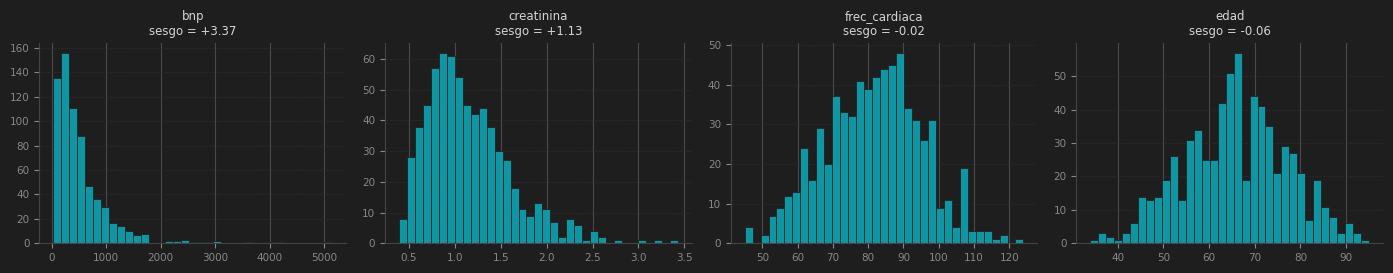

In [16]:
# Lista de variables numéricas que queremos analizar.
# Estas cuatro variables serán evaluadas tanto estadísticamente
# como mediante histogramas.
objetivo = ["bnp", "creatinina", "frec_cardiaca", "edad"]


# perfil(df_tr, objetivo):
# utiliza la función perfil() que definimos anteriormente.
#
# Para cada variable calcula:
# - sesgo
# - mínimo
# - número de negativos
# - número de ceros
# - lambda óptima de Yeo-Johnson
# - intervalo de confianza de lambda
# - si ese intervalo contiene 1
#
# .to_string(index=False):
# imprime la tabla completa sin mostrar el índice de Pandas.
print(perfil(df_tr, objetivo).to_string(index=False))


# ============================================================
# CREACIÓN DE LOS HISTOGRAMAS
# ============================================================

# plt.subplots(1, 4):
# crea una figura con 1 fila y 4 gráficas.
#
# figsize=(14, 2.8):
# define el tamaño total de la figura.
#
# facecolor="#1E1E1E":
# establece un fondo oscuro para toda la figura.
#
# fig:
# representa la figura completa.
#
# ax:
# contiene los 4 ejes individuales,
# es decir, los cuatro espacios donde se dibujarán histogramas.
fig, ax = plt.subplots(
    1,
    4,
    figsize=(14, 2.8),
    facecolor="#1E1E1E"
)


# zip(ax, objetivo):
# empareja cada eje con una variable.
#
# Ejemplo:
# primer eje  -> bnp
# segundo eje -> creatinina
# tercer eje  -> frec_cardiaca
# cuarto eje  -> edad
#
# a representa el eje actual.
# v representa el nombre de la variable actual.
for a, v in zip(ax, objetivo):

    # Cambia el color de fondo del área específica
    # donde se dibuja cada histograma.
    a.set_facecolor("#1E1E1E")


    # Crea el histograma de la variable actual.
    a.hist(

        # Datos que serán representados.
        df_tr[v],

        # Divide el rango de datos en 35 intervalos o "bins".
        # Cada barra representa cuántos valores caen
        # dentro de uno de esos intervalos.
        bins=35,

        # Color de relleno de las barras.
        color="#0FA3B1",

        # Color del borde de cada barra.
        edgecolor="#1E1E1E",

        # Grosor del borde de las barras.
        linewidth=0.6,

        # Transparencia:
        # 1 = completamente opaco
        # 0 = completamente transparente.
        alpha=0.9,
    )


    # ========================================================
    # CÁLCULO DEL SESGO
    # ========================================================

    # stats.skew():
    # calcula el coeficiente de asimetría de la variable actual.
    #
    # sesgo ≈ 0 -> distribución aproximadamente simétrica
    # sesgo > 0 -> cola hacia la derecha
    # sesgo < 0 -> cola hacia la izquierda
    sk = stats.skew(df_tr[v])


    # ========================================================
    # TÍTULO DE CADA HISTOGRAMA
    # ========================================================

    # Coloca como título:
    #
    # nombre de la variable
    # sesgo = valor
    #
    # \n genera un salto de línea.
    #
    # {sk:+.2f}:
    # muestra el valor con:
    # - signo + o -
    # - 2 decimales
    a.set_title(
        f"{v}\nsesgo = {sk:+.2f}",

        # Tamaño de letra del título.
        fontsize=8.5,

        # Color del título.
        color="#D4D4D4",

        # Separación entre el título y la gráfica.
        pad=6,

        # Peso de la fuente.
        fontweight="medium",
    )


    # ========================================================
    # LIMPIEZA Y FORMATO DE BORDES
    # ========================================================

    # Oculta el borde superior de la gráfica.
    a.spines["top"].set_visible(False)

    # Oculta el borde derecho.
    a.spines["right"].set_visible(False)

    # Cambia el color del borde izquierdo.
    a.spines["left"].set_color("#444444")

    # Cambia el color del borde inferior.
    a.spines["bottom"].set_color("#444444")


    # ========================================================
    # FORMATO DE LOS TICKS
    # ========================================================

    # tick_params controla las marcas y números
    # de los ejes X y Y.
    a.tick_params(

        # Color de los números y marcas.
        colors="#888888",

        # Tamaño de los números.
        labelsize=7.5,

        # Grosor de las pequeñas marcas de los ejes.
        width=0.8
    )


    # ========================================================
    # CUADRÍCULA
    # ========================================================

    # Agrega líneas horizontales de referencia.
    a.grid(

        # Solo se dibuja cuadrícula en el eje Y.
        axis="y",

        # Color de las líneas.
        color="#333333",

        # Línea discontinua.
        linestyle="--",

        # Grosor.
        linewidth=0.5,

        # Transparencia.
        alpha=0.7
    )


    # Hace que la cuadrícula se dibuje detrás
    # de las barras del histograma.
    a.set_axisbelow(True)


# Ajusta automáticamente los espacios entre las cuatro gráficas
# para evitar que títulos, ejes o etiquetas se encimen.
plt.tight_layout()


# Finalmente muestra la figura completa.
plt.show()

**Tarea.** Decide qué hacer con cada una de las cuatro variables. **No todas requieren lo mismo, y
al menos una no requiere nada.**

In [17]:
# ============================= TU TURNO =============================

# Decisiones de transformación:
#
# bnp           -> aplicar logaritmo
# creatinina    -> aplicar logaritmo
# frec_cardiaca -> no transformar
# edad          -> no transformar


# ============================================================
# BNP
# ============================================================

# BNP presenta un sesgo positivo alto (~ +3.2).
#
# Además:
# - su valor mínimo es positivo (33)
# - no tiene ceros
# - no tiene valores negativos
#
# Por lo tanto, es posible aplicar el logaritmo natural directamente.
#
# np.log() comprime especialmente los valores grandes,
# ayudando a reducir la cola hacia la derecha de la distribución.
df_tr["bnp"] = np.log(df_tr["bnp"])


# Se aplica exactamente la misma transformación al conjunto de prueba.
#
# Como el logaritmo es una transformación matemática fija
# y no aprende parámetros a partir de los datos,
# se puede aplicar directamente en train y test.
df_te["bnp"] = np.log(df_te["bnp"])


# ============================================================
# CREATININA
# ============================================================

# Creatinina también presenta sesgo positivo (~ +1).
#
# Su mínimo es 0.32, por lo que todos sus valores son positivos.
#
# Esto permite aplicar directamente el logaritmo natural.
df_tr["creatinina"] = np.log(df_tr["creatinina"])


# Se aplica la misma transformación al conjunto de prueba.
df_te["creatinina"] = np.log(df_te["creatinina"])


# ============================================================
# FRECUENCIA CARDIACA
# ============================================================

# Para frec_cardiaca, el intervalo de confianza del lambda
# de Yeo-Johnson contiene 1.
#
# Lambda = 1 corresponde aproximadamente a no aplicar
# una transformación de potencia.
#
# Por eso se conserva la variable en su escala original.


# ============================================================
# EDAD
# ============================================================

# Para edad ocurre lo mismo:
# el IC 95 % de lambda contiene 1.
#
# Por lo tanto, no hay suficiente evidencia en este análisis
# para justificar una transformación.
#
# La variable se conserva en su escala original.


# ============================================================
# COMPROBACIÓN DEL SESGO DESPUÉS DE LAS DECISIONES
# ============================================================

# Recorre nuevamente las cuatro variables analizadas.
for v in objetivo:

    # stats.skew(df_tr[v]):
    # calcula el sesgo de la variable DESPUÉS de haber aplicado
    # las transformaciones anteriores.
    #
    # Esto permite comprobar si el logaritmo realmente redujo
    # la asimetría de BNP y creatinina.
    #
    # %-18s:
    # imprime el nombre de la variable en un espacio de 18 caracteres
    # y lo alinea hacia la izquierda.
    #
    # %+.2f:
    # imprime el sesgo con signo (+/-) y dos decimales.
    print(
        "%-18s sesgo tras la decisión: %+.2f"
        % (v, stats.skew(df_tr[v]))
    )

bnp                sesgo tras la decisión: +0.09
creatinina         sesgo tras la decisión: +0.04
frec_cardiaca      sesgo tras la decisión: -0.02
edad               sesgo tras la decisión: -0.06


> | Variable | Decisión | Evidencia numérica |
> |---|---|---|
> | `bnp` | **Logaritmo** | Sesgo superior a +3, mínimo 33.3, sin ceros ni negativos. λ ≈ 0.00 con IC 95 % [−0.07, +0.06]: la verosimilitud selecciona precisamente la transformación logarítmica. El sesgo posterior cae a ≈ 0.00 |
> | `creatinina` | **Logaritmo** | Sesgo cercano a +1, dominio estrictamente positivo (mínimo 0.32). El sesgo posterior baja a ≈ −0.1 |
> | `frec_cardiaca` | **No se transforma** | Sesgo ≈ +0.09, ya simétrica. λ ≈ 0.79 con **IC 95 % que contiene 1.0** |
> | `edad` | **No se transforma** | Sesgo ≈ −0.06, ya simétrica. λ ≈ 1.09 con **IC 95 % que contiene 1.0** |
>
> Dos de las cuatro variables **no requieren transformación alguna**. Aplicarles una añadiría una capa que
> dificulta la interpretación clínica sin ganancia estadística demostrable. La restricción también es una decisión.
</div>

---
## Punto 7 — Escalamiento
*Subtema 4.6*

In [18]:
# Lista final de variables numéricas que se quieren revisar.
# Estas son las variables que ya pasaron por el proceso de limpieza,
# imputación y, cuando correspondía, transformación.
num_final = [
    "edad",
    "frec_cardiaca",
    "presion_sistolica",
    "bnp",
    "creatinina",
    "colesterol_total"
]


# df_tr[num_final]:
# selecciona únicamente las variables numéricas finales.
#
# .describe():
# calcula estadísticas descriptivas como:
# count, mean, std, min, 25%, 50%, 75% y max.
#
# .T:
# transpone la tabla.
# Esto hace que las variables aparezcan como filas
# y las estadísticas como columnas.
#
# [["mean", "std", "min", "50%", "max"]]:
# conserva solamente las estadísticas que interesan:
# media, desviación estándar, mínimo, mediana y máximo.
#
# .round(2):
# redondea todos los resultados a 2 decimales.
#
# .to_string():
# muestra la tabla completa como texto.
print(
    df_tr[num_final]
    .describe()
    .T[["mean", "std", "min", "50%", "max"]]
    .round(2)
    .to_string()
)


# Imprime un salto de línea y el título
# de la siguiente parte del análisis.
print("\nSesgo residual:")


# df_tr[num_final]:
# selecciona nuevamente las variables numéricas.
#
# .apply(...):
# ejecuta una función sobre cada columna.
#
# lambda s:
# representa temporalmente cada columna como una Serie.
#
# stats.skew(s):
# calcula el sesgo de esa columna.
#
# float(...):
# convierte el resultado a un número float estándar de Python.
#
# round(..., 2):
# redondea el sesgo a 2 decimales.
#
# .to_string():
# imprime todos los resultados como texto.
print(
    df_tr[num_final]
    .apply(
        lambda s: round(
            float(stats.skew(s)),
            2
        )
    )
    .to_string()
)

                     mean    std    min     50%     max
edad                65.84  11.29  34.00   66.00   95.00
frec_cardiaca       81.54  13.64  45.00   82.00  124.00
presion_sistolica  128.27  18.74  80.00  127.00  185.00
bnp                  5.94   0.82   3.55    5.94    8.55
creatinina           0.06   0.39  -0.94    0.06    1.23
colesterol_total   196.37  39.69  90.00  199.00  322.00

Sesgo residual:
edad                -0.06
frec_cardiaca       -0.02
presion_sistolica    0.21
bnp                  0.09
creatinina           0.04
colesterol_total    -0.13


**Tarea.** Escala las variables numéricas.

> Pregúntale al dato: *¿queda alguna cola pesada que arrastraría la media y la desviación estándar?*

In [19]:
# ============================= TU TURNO =============================

# Después de revisar las distribuciones, los sesgos residuales
# son suficientemente pequeños y no se observan colas extremadamente pesadas.
#
# Por eso se decide utilizar StandardScaler para todas las variables numéricas.
#
# MUY IMPORTANTE:
# el escalador se AJUSTA únicamente con el conjunto de entrenamiento.
# Así se evita utilizar información del conjunto de prueba.

# StandardScaler():
# crea el objeto que realizará la estandarización.
#
# .fit(df_tr[num_final]):
# calcula, para cada variable de entrenamiento:
# - la media
# - la desviación estándar
#
# Esos valores quedan guardados dentro de "escalador".
escalador = StandardScaler().fit(df_tr[num_final])


# transform():
# aplica la transformación utilizando las medias y desviaciones
# aprendidas anteriormente con TRAIN.
#
# La fórmula utilizada es aproximadamente:
#
# z = (x - media_train) / desviación_train
#
# El resultado reemplaza las columnas originales de entrenamiento.
df_tr[num_final] = escalador.transform(df_tr[num_final])


# Se transforma el conjunto de prueba usando EXACTAMENTE
# los parámetros aprendidos con entrenamiento.
#
# NO se vuelve a hacer fit con df_te.
df_te[num_final] = escalador.transform(df_te[num_final])


# Comprueba cómo quedaron las variables numéricas de entrenamiento.
#
# describe():
# calcula estadísticas descriptivas.
#
# .T:
# pone cada variable como fila.
#
# [["mean", "std", "min", "max"]]:
# muestra solamente media, desviación estándar,
# mínimo y máximo.
#
# Después del StandardScaler se espera:
# media ≈ 0
# desviación estándar ≈ 1
print(
    df_tr[num_final]
    .describe()
    .T[["mean", "std", "min", "max"]]
    .round(2)
    .to_string()
)

                   mean  std   min   max
edad               -0.0  1.0 -2.82  2.59
frec_cardiaca       0.0  1.0 -2.68  3.12
presion_sistolica  -0.0  1.0 -2.58  3.03
bnp                 0.0  1.0 -2.90  3.17
creatinina         -0.0  1.0 -2.58  3.00
colesterol_total    0.0  1.0 -2.68  3.17


> Tras el Punto 6 todos los sesgos residuales son pequeños y **ninguna variable conserva una cola pesada**.
> `StandardScaler` —media y desviación estándar— es apropiado, y produce variables comparables entre sí,
> que es lo que la regresión logística regularizada necesita.
>
> El escalador se ajusta **solo con entrenamiento** y se aplica a ambos conjuntos con el mismo objeto ya ajustado.
</div>

---
## Punto 8 — Entrenamiento y elección de la métrica
*Subtemas 3.5 y 3.1*

In [20]:
# Columnas que NO deben usarse como variables predictoras.
#
# id_paciente:
# es solamente un identificador, no una característica clínica útil.
#
# reingreso_30d:
# es la variable objetivo que queremos predecir,
# por lo tanto no puede estar dentro de X.
descartar = ["id_paciente", "reingreso_30d"]


# ============================================================
# CREACIÓN DE X DE ENTRENAMIENTO
# ============================================================

# df_tr.drop(columns=...):
# elimina las columnas indicadas del conjunto de entrenamiento.
#
# [c for c in descartar if c in df_tr.columns]:
# recorre la lista "descartar" y conserva únicamente
# las columnas que realmente existen dentro de df_tr.
#
# Esto evita un error si alguna de esas columnas ya hubiera sido eliminada.
X_tr = df_tr.drop(
    columns=[c for c in descartar if c in df_tr.columns]
)


# ============================================================
# CREACIÓN DE X DE PRUEBA
# ============================================================

# Hace exactamente lo mismo para el conjunto de prueba.
#
# X_te contendrá únicamente las variables predictoras
# que se utilizarán para evaluar el modelo.
X_te = df_te.drop(
    columns=[c for c in descartar if c in df_te.columns]
)


# ============================================================
# CREACIÓN DE y
# ============================================================

# y_tr:
# variable objetivo del conjunto de entrenamiento.
#
# y_te:
# variable objetivo del conjunto de prueba.
#
# Ambas contienen reingreso_30d, normalmente codificado:
# 0 = no reingreso
# 1 = reingreso.
y_tr, y_te = (
    df_tr["reingreso_30d"],
    df_te["reingreso_30d"]
)


# ============================================================
# VERIFICACIÓN DE QUE X SEA COMPLETAMENTE NUMÉRICA
# ============================================================

# X_tr.select_dtypes(exclude=np.number):
# selecciona todas las columnas que NO son numéricas.
#
# .empty:
# devuelve True si no encontró ninguna columna.
#
# assert:
# exige que esa condición sea verdadera.
#
# Si quedan columnas categóricas o de texto,
# el programa se detendrá y mostrará:
# "Quedan columnas no numéricas".
assert X_tr.select_dtypes(exclude=np.number).empty, \
    "Quedan columnas no numéricas"


# ============================================================
# REVISIÓN DEL TAMAÑO FINAL
# ============================================================

# X_tr.shape devuelve:
# (número de pacientes de entrenamiento,
#  número de variables predictoras)
#
# X_te.shape hace lo mismo para prueba.
print(
    "Matriz final -> train:",
    X_tr.shape,
    "| test:",
    X_te.shape
)


# ============================================================
# PREVALENCIA EN TEST
# ============================================================

# Como y_te contiene 0 y 1,
# su media equivale a la proporción de pacientes que reingresaron.
#
# %.4f muestra el resultado con cuatro decimales.
print(
    "Prevalencia en prueba: %.4f"
    % y_te.mean()
)


# ============================================================
# CREACIÓN Y ENTRENAMIENTO DEL MODELO
# ============================================================

# LogisticRegression():
# crea un modelo de regresión logística para clasificación binaria.
#
# solver="lbfgs":
# indica el algoritmo numérico que se utilizará
# para encontrar los coeficientes del modelo.
#
# max_iter=3000:
# permite hasta 3000 iteraciones para que el algoritmo converja.
#
# random_state=SEMILLA:
# mantiene especificada la semilla del flujo experimental.
#
# .fit(X_tr, y_tr):
# entrena el modelo utilizando:
# X_tr -> variables predictoras
# y_tr -> resultado real.
modelo = LogisticRegression(
    solver="lbfgs",
    max_iter=3000,
    random_state=SEMILLA
).fit(X_tr, y_tr)


# ============================================================
# PREDICCIONES
# ============================================================

# predict(X_te):
# devuelve directamente la clase predicha:
# 0 o 1.
pred = modelo.predict(X_te)


# predict_proba(X_te):
# devuelve la probabilidad estimada de pertenecer a cada clase.
#
# Por ejemplo, una fila podría devolver:
#
# [0.30, 0.70]
#
# donde:
# columna 0 -> probabilidad de clase 0
# columna 1 -> probabilidad de clase 1
#
# [:, 1]:
# selecciona únicamente la probabilidad de reingreso (clase 1).
prob = modelo.predict_proba(X_te)[:, 1]


# ============================================================
# RESULTADOS DEL MODELO
# ============================================================

print(
    "\n--- MODELO ------------------------------------------------------"
)


# Accuracy:
# proporción total de predicciones correctas.
print(
    "Accuracy : %.4f"
    % accuracy_score(y_te, pred)
)


# Recall:
# de todos los pacientes que realmente reingresaron,
# indica qué proporción fue detectada por el modelo.
print(
    "Recall   : %.4f"
    % recall_score(y_te, pred)
)


# AUC ROC:
# evalúa qué tan bien el modelo separa pacientes
# con reingreso y sin reingreso utilizando las probabilidades.
print(
    "AUC ROC  : %.4f"
    % roc_auc_score(y_te, prob)
)


# ============================================================
# MATRIZ DE CONFUSIÓN
# ============================================================

print(
    "\nMatriz de confusión "
    "[fila = real, columna = predicho]:"
)


# Compara las clases verdaderas y las predichas.
#
# Para un problema binario produce:
#
# [[TN, FP],
#  [FN, TP]]
print(
    confusion_matrix(y_te, pred)
)


# ============================================================
# REPORTE DE CLASIFICACIÓN
# ============================================================

# classification_report():
# muestra para cada clase:
#
# precision
# recall
# f1-score
# support
#
# digits=3:
# muestra tres decimales.
print(
    "\n",
    classification_report(
        y_te,
        pred,
        digits=3
    )
)


# ============================================================
# MODELO DE REFERENCIA / BASELINE
# ============================================================

print(
    "--- Referencia: clasificador trivial "
    "'nadie reingresa' ----------"
)


# np.zeros_like(y_te):
# genera un arreglo del mismo tamaño que y_te,
# pero lleno exclusivamente con ceros.
#
# Esto simula un clasificador extremadamente simple
# que siempre dice:
#
# "Este paciente NO va a reingresar".
#
# Después se calcula su accuracy para compararla
# contra la regresión logística.
print(
    "Accuracy : %.4f"
    % accuracy_score(
        y_te,
        np.zeros_like(y_te)
    )
)

Matriz final -> train: (675, 12) | test: (225, 12)
Prevalencia en prueba: 0.5067

--- MODELO ------------------------------------------------------
Accuracy : 0.6489
Recall   : 0.6228
AUC ROC  : 0.7579

Matriz de confusión [fila = real, columna = predicho]:
[[75 36]
 [43 71]]

               precision    recall  f1-score   support

           0      0.636     0.676     0.655       111
           1      0.664     0.623     0.643       114

    accuracy                          0.649       225
   macro avg      0.650     0.649     0.649       225
weighted avg      0.650     0.649     0.649       225

--- Referencia: clasificador trivial 'nadie reingresa' ----------
Accuracy : 0.4933


**Tarea.** Responde en prosa:

1. Compara la accuracy del modelo con la del clasificador trivial. ¿Cuánto aporta el modelo?
2. ¿Qué métrica reportarías aquí, y por qué?

> **1.** El clasificador trivial alcanza una accuracy cercana a **0.49**, porque la prevalencia de reingreso ronda
> el **50 %**. El modelo la supera con claridad, de modo que **aquí la accuracy sí es informativa**: la ganancia
> sobre el trivial es real y no un artefacto del desbalance.
>
> **2.** Se reportan **accuracy, recall y AUC** en conjunto. Con clases balanceadas la accuracy es interpretable,
> pero el recall sigue importando clínicamente: mide a cuántos de los pacientes que efectivamente reingresaron
> logramos identificar, que es la pregunta operativa del hospital.
>
> **La regla general:** la accuracy solo es interpretable **después** de compararla con el clasificador trivial.
> Esa comparación debe hacerse siempre, no solo cuando se sospecha desbalance.
</div>

---
# Retos finales

<div style="border-left:5px solid #E8912B;background:rgba(232, 145, 43, 0.08);color:#d4d4d4;padding:12px 16px;border-radius:5px;font-family:Calibri,Arial,sans-serif;">
<b style="color:#F5B041;">Cambio de formato</b><br>Los dos retos siguientes presentan variables donde <b>la respuesta de hoy no aplica</b>. Este es el tipo de reactivo que aparecer&aacute; en el examen. Resu&eacute;lvelos aunque no alcance el tiempo de clase.
</div>

## Reto A — Una variable con sesgo izquierdo

`fevi_ingreso` (fracción de eyección) es la variable que reservamos al inicio.

sesgo: -0.82
rango: [18, 66]
lambda = +2.19   IC 95% = [+1.95, +2.44]


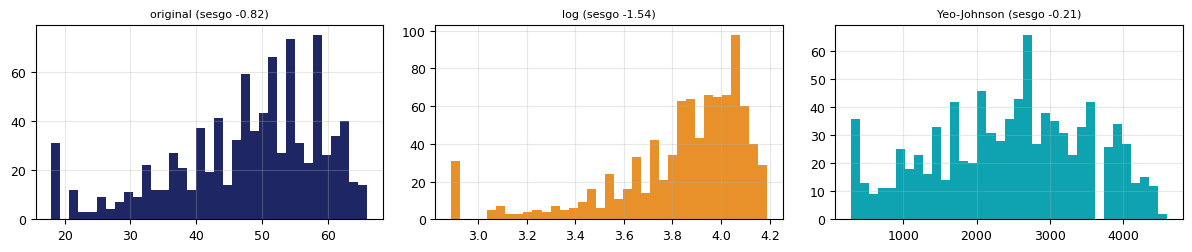

In [21]:
# ============================================================
# CARGAR NUEVAMENTE LOS DATOS ORIGINALES
# ============================================================

# Vuelve a cargar el archivo CSV original.
#
# Se usa "crudo" porque aquí queremos trabajar con los datos
# originales, antes de las transformaciones realizadas
# previamente en df_tr y df_te.
crudo = cargar("cohorte_ic_repaso.csv")


# Selecciona solamente la columna "fevi_ingreso".
#
# fevi será una Serie de Pandas que contiene
# los valores originales de esta variable.
fevi = crudo["fevi_ingreso"]


# ============================================================
# SESGO DE LA VARIABLE ORIGINAL
# ============================================================

# stats.skew(fevi):
# calcula el coeficiente de asimetría o sesgo de FEVI.
#
# float(...):
# convierte el resultado a un float estándar de Python.
#
# round(..., 2):
# redondea el sesgo a dos decimales.
print(
    "sesgo:",
    round(float(stats.skew(fevi)), 2)
)


# ============================================================
# RANGO DE LA VARIABLE
# ============================================================

# fevi.min():
# obtiene el valor mínimo observado.
#
# fevi.max():
# obtiene el valor máximo observado.
#
# %.0f:
# imprime los números sin decimales.
print(
    "rango: [%.0f, %.0f]"
    % (fevi.min(), fevi.max())
)


# ============================================================
# LAMBDA ÓPTIMA DE YEO-JOHNSON
# ============================================================

# Utiliza la función lambda_ic() definida al principio.
#
# Devuelve:
# lam = lambda óptima
# lo  = límite inferior del IC 95 %
# hi  = límite superior del IC 95 %
lam, lo, hi = lambda_ic(fevi)


# Imprime lambda y su intervalo de confianza.
#
# %+.2f:
# muestra el número con signo y dos decimales.
#
# %%:
# se utiliza para imprimir literalmente el símbolo %.
print(
    "lambda = %+.2f   IC 95%% = [%+.2f, %+.2f]"
    % (lam, lo, hi)
)


# ============================================================
# CREAR TRES HISTOGRAMAS
# ============================================================

# Crea una figura formada por:
# 1 fila
# 3 columnas
#
# Esto permite comparar las tres versiones de FEVI
# lado a lado.
#
# fig:
# representa la figura completa.
#
# ax:
# contiene los tres ejes donde se dibujarán
# los histogramas.
fig, ax = plt.subplots(
    1,
    3,
    figsize=(12, 2.6)
)


# ============================================================
# HISTOGRAMA 1: VARIABLE ORIGINAL
# ============================================================

# Dibuja el histograma de FEVI sin ninguna transformación.
#
# bins=35:
# divide el rango de valores en 35 intervalos.
#
# color:
# solamente controla la apariencia de las barras.
ax[0].hist(
    fevi,
    bins=35,
    color="#1E2664"
)


# Coloca como título:
# "original"
# y el sesgo de la variable original.
#
# {stats.skew(fevi):+.2f}
# muestra el sesgo con signo y dos decimales.
ax[0].set_title(
    f"original (sesgo {stats.skew(fevi):+.2f})",
    fontsize=8
)


# ============================================================
# HISTOGRAMA 2: TRANSFORMACIÓN LOGARÍTMICA
# ============================================================

# np.log(fevi):
# calcula el logaritmo natural de cada valor.
#
# Esta transformación comprime los valores altos
# y puede reducir un sesgo positivo.
ax[1].hist(
    np.log(fevi),
    bins=35,
    color="#E8912B"
)


# Calcula el sesgo DESPUÉS de aplicar el logaritmo
# y lo muestra en el título.
ax[1].set_title(
    f"log (sesgo {stats.skew(np.log(fevi)):+.2f})",
    fontsize=8
)


# ============================================================
# TRANSFORMACIÓN YEO-JOHNSON
# ============================================================

# fevi.to_numpy(float):
# convierte la Serie de Pandas a un arreglo NumPy
# de tipo float.
#
# stats.yeojohnson(...):
# aplica automáticamente la transformación Yeo-Johnson.
#
# Esta función devuelve dos resultados:
# 1. los datos transformados
# 2. el lambda utilizado
#
# [0]:
# selecciona solamente los datos transformados.
yj = stats.yeojohnson(
    fevi.to_numpy(float)
)[0]


# ============================================================
# HISTOGRAMA 3: YEO-JOHNSON
# ============================================================

# Dibuja el histograma de los valores
# transformados mediante Yeo-Johnson.
ax[2].hist(
    yj,
    bins=35,
    color="#0FA3B1"
)


# Calcula el sesgo de la variable transformada
# y lo muestra en el título.
ax[2].set_title(
    f"Yeo-Johnson (sesgo {stats.skew(yj):+.2f})",
    fontsize=8
)


# ============================================================
# AJUSTE FINAL DE LA FIGURA
# ============================================================

# Ajusta automáticamente los espacios entre gráficas
# para evitar que los títulos y ejes se encimen.
plt.tight_layout()


# Muestra la figura.
plt.show()

**Preguntas.**

1. ¿El logaritmo corrige el sesgo de esta variable? Mira el histograma central y su cifra de sesgo.
2. ¿Por qué λ resulta **mayor** que 1 aquí, cuando en `bnp` resultó ≈ 0?
3. Formula la regla general en una frase.

> **Tu respuesta:**

<br>

> **Respuesta.**
>
> **1. No.** El sesgo original es **negativo (≈ −0.82)**: la cola larga está a la **izquierda**. El logaritmo
> comprime los valores altos, es decir, actúa sobre la cola **derecha**. Aplicado aquí **agrava** el problema en
> lugar de corregirlo, como muestra el histograma central: el sesgo se vuelve más negativo.
>
> **2.** Porque λ y la dirección del sesgo están ligados. En la escalera de potencias, **λ < 1 comprime la cola
> derecha** (corrige sesgo derecho) y **λ > 1 expande hacia arriba** (corrige sesgo izquierdo). En `bnp`, con
> sesgo +3.17, la verosimilitud eligió λ ≈ 0, que es el logaritmo. Aquí, con sesgo −0.82, eligió **λ ≈ 2.19**,
> por encima de 1. El algoritmo no está haciendo nada extraño: está **subiendo** la escalera en lugar de bajarla.
>
> **3.** *El sesgo por sí solo no dicta la transformación: hay que leer su **dirección**, comprobar que el
> **dominio** admita la operación elegida, y verificar con el IC de λ que la corrección sea **necesaria**.*


## Reto B — Una variable con valores negativos

In [22]:
# ============================================================
# CREACIÓN DE UNA VARIABLE DERIVADA
# ============================================================

# Se crea una nueva variable llamada delta_bnp.
#
# Para cada paciente se calcula:
#
# delta_bnp = BNP - 400
#
# El valor 400 pg/mL se está utilizando en esta actividad
# como umbral clínico de referencia.
#
# La interpretación matemática es:
#
# delta_bnp > 0  -> BNP está por encima de 400
# delta_bnp = 0  -> BNP es exactamente 400
# delta_bnp < 0  -> BNP está por debajo de 400
delta_bnp = crudo["bnp"] - 400


# ============================================================
# REVISIÓN DEL SESGO
# ============================================================

# stats.skew(delta_bnp):
# calcula el sesgo o asimetría de la variable derivada.
#
# float():
# convierte el resultado a un float normal de Python.
#
# round(..., 2):
# redondea a dos decimales.
print(
    "sesgo:",
    round(float(stats.skew(delta_bnp)), 2)
)


# ============================================================
# REVISIÓN DEL DOMINIO DE LA VARIABLE
# ============================================================

# delta_bnp.min():
# obtiene el menor valor de delta_bnp.
#
# (delta_bnp < 0):
# identifica cuáles valores son negativos.
#
# .sum():
# cuenta cuántos valores negativos existen.
#
# (delta_bnp == 0):
# identifica valores exactamente iguales a cero.
#
# %.1f:
# muestra el mínimo con un decimal.
#
# %d:
# muestra los conteos como números enteros.
print(
    "mínimo: %.1f  |  negativos: %d  |  ceros: %d"
    % (
        delta_bnp.min(),
        int((delta_bnp < 0).sum()),
        int((delta_bnp == 0).sum())
    )
)


# ============================================================
# INTENTO DE APLICAR LOGARITMO
# ============================================================

# Imprime un título para indicar que ahora se probará
# qué ocurre al aplicar np.log().
print("\n¿Qué ocurre si aplicamos np.log() ?")


# np.log() normalmente genera advertencias cuando recibe:
#
# - valores negativos
# - ceros
#
# np.errstate() permite controlar temporalmente
# esas advertencias de NumPy.
#
# invalid="ignore":
# oculta advertencias generadas al intentar calcular
# logaritmos de números negativos.
#
# divide="ignore":
# oculta la advertencia producida por log(0),
# que genera -infinito.
#
# IMPORTANTE:
# esto NO corrige los valores.
# Solamente evita que aparezcan las advertencias en pantalla.
with np.errstate(invalid="ignore", divide="ignore"):

    # Intenta calcular el logaritmo natural de delta_bnp.
    #
    # Los valores positivos sí producirán resultados finitos.
    # Los ceros producirán -inf.
    # Los negativos producirán NaN.
    intento = np.log(delta_bnp)


# ============================================================
# CONTAR RESULTADOS NO FINITOS
# ============================================================

# np.isfinite(intento):
# devuelve True para valores numéricos finitos
# y False para:
#
# NaN
# +inf
# -inf
#
# ~ invierte los valores booleanos:
#
# True  -> False
# False -> True
#
# Por lo tanto:
# ~np.isfinite(intento)
# identifica precisamente los resultados NO finitos.
#
# .sum():
# cuenta cuántos existen.
print(
    "  valores no finitos generados:",
    int((~np.isfinite(intento)).sum()),
    "de",
    len(delta_bnp)
)

sesgo: 3.17
mínimo: -366.7  |  negativos: 480  |  ceros: 0

¿Qué ocurre si aplicamos np.log() ?
  valores no finitos generados: 480 de 900


**Tarea.** El sesgo es positivo y fuerte, así que "hay que transformar". Pero `np.log()` destruye
la mayor parte de la columna.

Aplica la transformación adecuada y comprueba el sesgo resultante.


In [23]:
# ============================= TU TURNO =============================

# delta_bnp contiene valores negativos, posiblemente ceros
# y también valores positivos.
#
# Por eso NO se puede aplicar directamente el logaritmo,
# ya que log(x) requiere x > 0.
#
# Yeo-Johnson sí puede trabajar con:
# x < 0
# x = 0
# x > 0


# Crea un transformador de potencia usando el método Yeo-Johnson.
#
# method="yeo-johnson":
# indica qué transformación se utilizará.
#
# standardize=False:
# indica que SOLO queremos aplicar la transformación de potencia.
# No queremos que PowerTransformer estandarice automáticamente
# el resultado a media 0 y desviación estándar 1.
pt = PowerTransformer(
    method="yeo-johnson",
    standardize=False
)


# delta_bnp originalmente es una Serie de Pandas, es decir,
# una estructura de una sola dimensión.
#
# .to_frame():
# la convierte en un DataFrame de una sola columna,
# porque scikit-learn espera que X tenga forma:
#
# (número de observaciones, número de variables)
#
# .fit_transform():
# hace dos cosas:
#
# 1. fit:
#    estima el valor óptimo de lambda utilizando los datos.
#
# 2. transform:
#    aplica la transformación Yeo-Johnson usando ese lambda.
#
# El resultado es una matriz 2D de tamaño:
# (número de pacientes, 1 columna)
#
# [:, 0]:
# selecciona todas las filas de la primera columna
# para volver a obtener un arreglo de una sola dimensión.
delta_yj = pt.fit_transform(
    delta_bnp.to_frame()
)[:, 0]


# ============================================================
# LAMBDA ESTIMADA
# ============================================================

# Después de ejecutar fit(), PowerTransformer guarda
# los lambdas estimados en el atributo:
#
# pt.lambdas_
#
# Como solamente estamos transformando una variable,
# lambdas_ contiene un solo valor.
#
# [0]:
# selecciona ese primer y único lambda.
#
# %+.3f:
# muestra el número:
# - con signo
# - con tres decimales.
print(
    "lambda estimada: %+.3f"
    % pt.lambdas_[0]
)


# ============================================================
# SESGO ORIGINAL
# ============================================================

# Calcula el sesgo de delta_bnp ANTES de transformarla.
#
# Esto sirve como punto de referencia para poder comparar
# si Yeo-Johnson realmente mejoró la simetría.
print(
    "sesgo original : %+.2f"
    % stats.skew(delta_bnp)
)


# ============================================================
# SESGO DESPUÉS DE YEO-JOHNSON
# ============================================================

# Calcula el sesgo después de aplicar la transformación.
#
# Si el valor queda más cerca de 0 que el sesgo original,
# significa que la transformación redujo la asimetría.
print(
    "sesgo tras YJ  : %+.2f"
    % stats.skew(delta_yj)
)


# ============================================================
# COMPROBACIÓN DE VALORES NO FINITOS
# ============================================================

# np.isfinite(delta_yj):
# devuelve True para números válidos y finitos.
#
# Devuelve False para:
# NaN
# +inf
# -inf
#
# ~:
# invierte True y False.
#
# Entonces:
# ~np.isfinite(delta_yj)
# identifica los valores problemáticos.
#
# .sum():
# cuenta cuántos existen.
#
# Si Yeo-Johnson funcionó correctamente,
# lo esperado es obtener 0.
print(
    "valores no finitos:",
    int((~np.isfinite(delta_yj)).sum())
)

lambda estimada: +0.856
sesgo original : +3.17
sesgo tras YJ  : +0.42
valores no finitos: 0


> **Tu conclusión en una frase:**

<br>

> **Conclusión.**
>
> El logaritmo genera `NaN` o `-inf` en cerca de la mitad de las filas, porque **su dominio exige valores
> estrictamente positivos**. Yeo-Johnson está definido para todo el eje real —negativos, cero y positivos— y
> corrige el sesgo sin perder una sola observación.
>
> **La regla:** antes de elegir una transformación, revisa el **mínimo** y el **conteo de negativos y ceros**.
> Si hay alguno, el logaritmo queda descartado sin más discusión.
</div>

---
# Mapa de decisiones — guía de estudio

**Esta tabla es lo que debes estudiar.** No las celdas de código: **las preguntas de la columna central**.

| # | Punto de decisión | La pregunta que le haces al dato | Hoy la respuesta fue |
|---|---|---|---|
| 1 | Integridad y segregación | ¿La fila y la unidad de observación son la misma cosa? | Sí (900 filas = 900 pacientes) → partición estándar |
| 2 | Variables admisibles | ¿Alguna variable se registra **después** del desenlace? | No → no se elimina nada |
| 3 | Atípicos | ¿Este valor es **raro** o es **imposible**? | Colesterol 0 = imposible (corregir) · BNP alto = real (conservar) |
| 4 | Faltantes | ¿El **hecho de que falte** me dice algo? | No (MCAR) → imputación simple, sin indicador |
| 5 | Codificación | ¿Los niveles tienen un **orden monótono** verificable? | No → one-hot para las tres |
| 6 | Corrección del sesgo | ¿Qué **dirección**? ¿El **dominio** admite log? ¿El **IC de λ** excluye a 1? | Log en `bnp` y `creatinina` · sin transformar en las otras dos |
| 7 | Escalamiento | ¿Queda alguna **cola pesada** que arrastre la media? | No → `StandardScaler` |
| 8 | Métrica | ¿Cuánto supero al **clasificador trivial**? | Bastante (≈ 50 % de prevalencia) → accuracy interpretable |

### En el examen

Los ocho puntos serán **los mismos** y en **el mismo orden**. El conjunto de datos será distinto, y por eso
**varias respuestas de la última columna serán otras**. El examen es enteramente práctico y dura 90 minutos.

Se te calificará en tres componentes por punto: **ejecución** (el código corre), **decisión** (elegiste lo que
el dato exige) y **justificación** (citaste la evidencia numérica). Una decisión correcta sin evidencia que la
respalde vale la mitad, y una decisión equivocada que tú mismo detectes y corrijas conserva puntaje parcial.

### Lista de verificación antes del examen

- [ ] Sé comprobar si hay registros duplicados por sujeto, y qué hacer si los hay.
- [ ] Sé distinguir un error de captura de un valor extremo clínicamente válido.
- [ ] Sé comparar el perfil de los casos con y sin dato faltante para decidir si la ausencia es informativa.
- [ ] Sé verificar si una variable categórica tiene orden monótono antes de codificarla.
- [ ] Sé leer la **dirección** del sesgo, no solo su magnitud.
- [ ] Sé revisar el mínimo y el conteo de negativos antes de intentar un logaritmo.
- [ ] Sé interpretar el IC 95 % de λ para decidir **no** transformar.
- [ ] Sé calcular el desempeño del clasificador trivial y comparar contra él.


In [ ]:
# ============================================================
# PLANTILLA DE APOYO PARA EL EXAMEN
# ============================================================
# IDEA:
# PREGUNTA -> EVIDENCIA NUMÉRICA -> DECISIÓN -> JUSTIFICACIÓN
#
# IMPORTANTE:
# - Cambia los nombres de columnas según el dataset del examen.
# - NUNCA uses test para calcular medianas, lambdas o escaladores.
# - "Atípico" NO significa automáticamente "error".
# - El código no puede decidir si una variable es clínicamente imposible
#   o si fue registrada después del desenlace: eso lo decides tú.
# ============================================================


# ============================================================
# 0. LIBRERÍAS Y CONFIGURACIÓN
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

SEMILLA = 42


# ============================================================
# CAMBIA ESTO AL INICIO DEL EXAMEN
# ============================================================

ARCHIVO = "TU_ARCHIVO.csv"

ID = "id_paciente"             # columna identificadora
TARGET = "reingreso_30d"       # variable que quieres predecir

# Variables que sabes que NO deben entrar al modelo:
# - identificador
# - target
# - variables registradas DESPUÉS del desenlace
NO_USAR = [ID, TARGET]

# Ejemplo:
# NO_USAR = [ID, TARGET, "variable_post_des_enlace"]


# ============================================================
# FUNCIONES DE APOYO
# ============================================================

def lambda_ic(x, alpha=0.05):
    """
    Lambda óptima Yeo-Johnson + IC 95%.
    Si el IC contiene 1, dejar la variable sin transformar
    es una decisión defendible.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    lam = stats.yeojohnson_normmax(x)

    corte = (
        stats.yeojohnson_llf(lam, x)
        - 0.5 * stats.chi2.ppf(1 - alpha, 1)
    )

    malla = np.linspace(lam - 6, lam + 6, 2001)

    llf = np.array([
        stats.yeojohnson_llf(l, x)
        for l in malla
    ])

    dentro = malla[llf >= corte]

    return lam, dentro.min(), dentro.max()


def perfil(df, columnas):
    """
    Diagnóstico para decidir transformaciones.
    """
    filas = []

    for c in columnas:

        s = df[c].dropna().astype(float)

        lam, lo, hi = lambda_ic(s)

        filas.append({
            "variable": c,
            "sesgo": round(float(stats.skew(s)), 2),
            "min": round(float(s.min()), 2),
            "max": round(float(s.max()), 2),
            "negativos": int((s < 0).sum()),
            "ceros": int((s == 0).sum()),
            "lambda": round(lam, 3),
            "IC_inf": round(lo, 2),
            "IC_sup": round(hi, 2),
            "IC_contiene_1": bool(lo <= 1 <= hi)
        })

    return pd.DataFrame(filas)


def limites_iqr(s):
    """
    Límites de Tukey para detectar posibles valores atípicos.
    """
    q1, q3 = s.quantile([0.25, 0.75])

    iqr = q3 - q1

    return q1 - 1.5 * iqr, q3 + 1.5 * iqr


def revisar_atipicos(df, columnas):
    """
    Muestra evidencia numérica de posibles atípicos.
    NO elimina nada.
    """
    for v in columnas:

        s = df[v].dropna()

        lo, hi = limites_iqr(s)

        n_atipicos = ((s < lo) | (s > hi)).sum()

        print(
            f"{v:22s} "
            f"IQR=[{lo:8.2f}, {hi:8.2f}] "
            f"atípicos={n_atipicos:4d} "
            f"min={s.min():8.2f} "
            f"max={s.max():8.2f} "
            f"ceros={(s == 0).sum():4d}"
        )


# ============================================================
# CARGAR DATOS
# ============================================================

df = pd.read_csv(ARCHIVO)

print("Dimensiones:", df.shape)
print("\nTipos:")
print(df.dtypes.to_string())

print("\nDistribución del desenlace:")
print(
    df[TARGET]
    .value_counts(normalize=True)
    .round(3)
    .to_string()
)


# ============================================================
# 1. INTEGRIDAD Y SEGREGACIÓN
# ============================================================
# PREGUNTA:
# ¿La fila y la unidad de observación son la misma cosa?
# ============================================================

print("\n" + "=" * 60)
print("1. INTEGRIDAD Y SEGREGACIÓN")
print("=" * 60)

n_filas = len(df)
n_ids = df[ID].nunique()

print("Filas:            ", n_filas)
print("Unidades únicas:  ", n_ids)
print("Filas excedentes: ", n_filas - n_ids)


# DECISIÓN:
# Si filas == IDs únicos:
# -> cada fila representa una unidad
# -> partición estándar es correcta.
#
# Si NO coinciden:
# -> NO hagas split estándar a ciegas.
# -> un mismo paciente podría caer en train y test.
# -> revisa si debes agrupar/dividir por paciente.


# ============================================================
# 2. VARIABLES ADMISIBLES
# ============================================================
# PREGUNTA:
# ¿Alguna variable se registra DESPUÉS del desenlace?
#
# ESTO NO LO PUEDE DECIDIR PYTHON.
# Revisa el significado de las columnas.
# ============================================================

print("\n" + "=" * 60)
print("2. VARIABLES ADMISIBLES")
print("=" * 60)

print(df.columns.tolist())

print("""
Revisa cada variable:
¿existía en el momento en que habría que hacer la predicción?

Si una variable ocurre DESPUÉS del desenlace:
-> agregarla a NO_USAR.
""")


# ============================================================
# HACER SPLIT
# ============================================================
# SOLO si ya decidiste que la partición por filas es correcta.
# ============================================================

df_tr, df_te = train_test_split(
    df,
    test_size=0.25,
    random_state=SEMILLA,
    stratify=df[TARGET]
)

df_tr = df_tr.copy().reset_index(drop=True)
df_te = df_te.copy().reset_index(drop=True)

print("\nTrain / Test:", len(df_tr), "/", len(df_te))
print("Prevalencia train:", round(df_tr[TARGET].mean(), 4))
print("Prevalencia test :", round(df_te[TARGET].mean(), 4))


# ============================================================
# 3. VALORES ATÍPICOS
# ============================================================
# PREGUNTA:
# ¿El valor es RARO o IMPOSIBLE?
#
# IQR solo detecta rareza estadística.
# El contexto decide si se corrige.
# ============================================================

print("\n" + "=" * 60)
print("3. ATÍPICOS")
print("=" * 60)

numericas = (
    df_tr
    .select_dtypes(include=np.number)
    .columns
    .drop(TARGET, errors="ignore")
)

revisar_atipicos(df_tr, numericas)


# ----- AQUÍ TOMAS TU DECISIÓN -----
#
# EJEMPLO si descubres que 0 es imposible:
#
# df_tr["colesterol"] = df_tr["colesterol"].replace(0, np.nan)
# df_te["colesterol"] = df_te["colesterol"].replace(0, np.nan)
#
#
# Si un valor es extremo pero REAL:
# -> NO LO TOQUES.
#
# Ejemplo:
# BNP muy alto pero fisiológicamente plausible -> conservar.


# ============================================================
# 4. FALTANTES
# ============================================================
# PREGUNTA:
# ¿EL HECHO DE QUE FALTE EL DATO ME DICE ALGO?
# ============================================================

print("\n" + "=" * 60)
print("4. FALTANTES")
print("=" * 60)

faltantes = (
    df_tr.isna().mean() * 100
).round(1)

print(
    faltantes
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
    .to_string()
)


# ------------------------------------------------------------
# PARA INVESTIGAR UNA VARIABLE CON FALTANTES:
# CAMBIA "VARIABLE_FALTANTE"
# ------------------------------------------------------------

VARIABLE_FALTANTE = None

# Ejemplo:
# VARIABLE_FALTANTE = "colesterol_total"

if VARIABLE_FALTANTE is not None:

    falta = df_tr[VARIABLE_FALTANTE].isna()

    comparar = [
        c for c in numericas
        if c != VARIABLE_FALTANTE
    ][:5]

    if TARGET not in comparar:
        comparar.append(TARGET)

    print("\nComparación con/sin dato:")

    print(
        df_tr
        .groupby(falta)[comparar]
        .mean()
        .round(2)
        .to_string()
    )


# ------------------------------------------------------------
# IMPUTACIÓN SIMPLE CON MEDIANA
# SOLO si decidiste que es apropiado.
# ------------------------------------------------------------

IMPUTAR_MEDIANA = []

# Ejemplo:
# IMPUTAR_MEDIANA = ["colesterol_total"]

for v in IMPUTAR_MEDIANA:

    mediana = df_tr[v].median()

    df_tr[v] = df_tr[v].fillna(mediana)
    df_te[v] = df_te[v].fillna(mediana)

    print(
        f"{v}: mediana TRAIN usada = {mediana:.3f}"
    )


# ============================================================
# 5. CODIFICACIÓN
# ============================================================
# PREGUNTA:
# ¿Los niveles tienen un ORDEN MONÓTONO VERIFICABLE?
#
# NO -> nominal -> one-hot
# SÍ -> puede justificarse codificación ordinal
# ============================================================

print("\n" + "=" * 60)
print("5. CODIFICACIÓN")
print("=" * 60)

categoricas = df_tr.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categóricas encontradas:", categoricas)

for v in categoricas:

    print(
        f"\n{v}: "
        f"{df_tr[v].nunique()} niveles"
    )

    print(sorted(df_tr[v].dropna().unique()))


# ------------------------------------------------------------
# ESCRIBE AQUÍ LAS QUE DECIDISTE QUE SON NOMINALES
# ------------------------------------------------------------

NOMINALES = categoricas.copy()

# Si algunas NO deben hacer one-hot, modifica la lista.
#
# Ejemplo:
# NOMINALES = ["sexo", "tipo_dolor", "pendiente_st"]


if len(NOMINALES) > 0:

    df_tr = pd.get_dummies(
        df_tr,
        columns=NOMINALES,
        drop_first=True,
        dtype=int
    )

    df_te = pd.get_dummies(
        df_te,
        columns=NOMINALES,
        drop_first=True,
        dtype=int
    )

    # TEST queda exactamente con las columnas de TRAIN.
    df_te = df_te.reindex(
        columns=df_tr.columns,
        fill_value=0
    )


print(
    "Columnas después de codificar:",
    df_tr.shape[1]
)


# ============================================================
# 6. CORRECCIÓN DEL SESGO
# ============================================================
# PREGUNTAS:
#
# 1. ¿Hay sesgo importante?
# 2. ¿Hacia qué dirección?
# 3. ¿El dominio admite log?
# 4. ¿El IC de lambda contiene 1?
#
# REGLA MENTAL:
#
# IC lambda contiene 1
# -> NO transformar es defendible
#
# Sesgo positivo + todos x > 0
# -> considerar log
#
# Hay x <= 0
# -> log directo NO
# -> considerar Yeo-Johnson
# ============================================================

print("\n" + "=" * 60)
print("6. CORRECCIÓN DEL SESGO")
print("=" * 60)

numericas_actuales = [
    c for c in df_tr.select_dtypes(include=np.number).columns
    if c not in NO_USAR
]

print(
    perfil(df_tr, numericas_actuales)
    .to_string(index=False)
)


# ------------------------------------------------------------
# HISTOGRAMAS
# ------------------------------------------------------------

n = len(numericas_actuales)

if n > 0:

    cols = min(4, n)
    filas = int(np.ceil(n / cols))

    fig, axes = plt.subplots(
        filas,
        cols,
        figsize=(4 * cols, 2.8 * filas)
    )

    axes = np.array(axes).reshape(-1)

    for a, v in zip(axes, numericas_actuales):

        a.hist(df_tr[v].dropna(), bins=30)

        a.set_title(
            f"{v}\nskew={stats.skew(df_tr[v].dropna()):+.2f}",
            fontsize=8
        )

    # Apagar ejes sobrantes
    for a in axes[len(numericas_actuales):]:
        a.axis("off")

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# VARIABLES QUE DECIDAS TRANSFORMAR
# ------------------------------------------------------------

LOG_VARS = []
YJ_VARS = []

# EJEMPLOS:
#
# LOG_VARS = ["bnp", "creatinina"]
# YJ_VARS = ["variable_con_negativos"]


# ---- LOG ----

for v in LOG_VARS:

    # Comprobación de seguridad
    print(
        f"{v}: mínimo train = {df_tr[v].min():.3f}"
    )

    if (df_tr[v] <= 0).any():
        print(
            f"ADVERTENCIA: {v} contiene x <= 0. "
            "NO aplicar log directamente."
        )

    else:
        df_tr[v] = np.log(df_tr[v])
        df_te[v] = np.log(df_te[v])


# ---- YEO-JOHNSON ----

transformadores_yj = {}

for v in YJ_VARS:

    pt = PowerTransformer(
        method="yeo-johnson",
        standardize=False
    )

    # FIT SOLO TRAIN
    df_tr[v] = (
        pt.fit_transform(df_tr[[v]])[:, 0]
    )

    # TEST SOLO TRANSFORM
    df_te[v] = (
        pt.transform(df_te[[v]])[:, 0]
    )

    transformadores_yj[v] = pt

    print(
        f"{v}: lambda YJ = {pt.lambdas_[0]:+.3f}"
    )


print("\nSesgos después de decisiones:")

for v in numericas_actuales:

    print(
        f"{v:25s} "
        f"{stats.skew(df_tr[v].dropna()):+.2f}"
    )


# ============================================================
# 7. ESCALAMIENTO
# ============================================================
# PREGUNTA:
# ¿QUEDAN COLAS PESADAS / OUTLIERS QUE ARRASTREN LA MEDIA?
#
# NO -> StandardScaler
# SÍ -> considerar RobustScaler
#
# FIT SOLO EN TRAIN
# ============================================================

print("\n" + "=" * 60)
print("7. ESCALAMIENTO")
print("=" * 60)

num_final = [
    c for c in df_tr.select_dtypes(include=np.number).columns
    if c not in NO_USAR
]

print(
    df_tr[num_final]
    .describe()
    .T[["mean", "std", "min", "50%", "max"]]
    .round(2)
    .to_string()
)


# ------------------------------------------------------------
# ELIGE UNO:
# "standard" o "robust"
# ------------------------------------------------------------

TIPO_ESCALADOR = "standard"


if TIPO_ESCALADOR == "standard":

    escalador = StandardScaler()

elif TIPO_ESCALADOR == "robust":

    escalador = RobustScaler()

else:

    raise ValueError(
        "TIPO_ESCALADOR debe ser 'standard' o 'robust'"
    )


# FIT SOLO TRAIN
escalador.fit(df_tr[num_final])

# Aplicar los mismos parámetros a ambos
df_tr[num_final] = escalador.transform(
    df_tr[num_final]
)

df_te[num_final] = escalador.transform(
    df_te[num_final]
)


print("\nDespués del escalamiento:")

print(
    df_tr[num_final]
    .describe()
    .T[["mean", "std", "min", "max"]]
    .round(2)
    .to_string()
)


# ============================================================
# 8. MODELO Y MÉTRICAS
# ============================================================
# PREGUNTA:
# ¿CUÁNTO SUPERO AL CLASIFICADOR TRIVIAL?
# ============================================================

print("\n" + "=" * 60)
print("8. MODELO Y MÉTRICAS")
print("=" * 60)


# Columnas que realmente existan
descartar_existentes = [
    c for c in NO_USAR
    if c in df_tr.columns
]

X_tr = df_tr.drop(
    columns=descartar_existentes
)

X_te = df_te.drop(
    columns=descartar_existentes
)

y_tr = df_tr[TARGET]
y_te = df_te[TARGET]


# Comprobar que X sea completamente numérica
assert X_tr.select_dtypes(
    exclude=np.number
).empty, "ERROR: todavía quedan columnas no numéricas"


# Comprobar consistencia
assert list(X_tr.columns) == list(X_te.columns), \
    "ERROR: train y test tienen columnas distintas"


print(
    "Matriz final:",
    X_tr.shape,
    X_te.shape
)

print(
    "Prevalencia test:",
    round(y_te.mean(), 4)
)


# ------------------------------------------------------------
# REGRESIÓN LOGÍSTICA
# ------------------------------------------------------------

modelo = LogisticRegression(
    solver="lbfgs",
    max_iter=3000,
    random_state=SEMILLA
)

modelo.fit(X_tr, y_tr)


# Predicción de clase
pred = modelo.predict(X_te)

# Probabilidad de la clase 1
prob = modelo.predict_proba(X_te)[:, 1]


# ------------------------------------------------------------
# MÉTRICAS
# ------------------------------------------------------------

acc = accuracy_score(y_te, pred)
rec = recall_score(y_te, pred)
auc = roc_auc_score(y_te, prob)

print("\n--- MODELO ---")

print("Accuracy:", round(acc, 4))
print("Recall:  ", round(rec, 4))
print("AUC ROC: ", round(auc, 4))

print("\nMatriz de confusión:")
print(confusion_matrix(y_te, pred))

print("\nClassification report:")
print(
    classification_report(
        y_te,
        pred,
        digits=3
    )
)


# ============================================================
# CLASIFICADOR TRIVIAL
# ============================================================
# En vez de asumir que la clase mayoritaria siempre es 0,
# obtenemos la mayoría desde TRAIN.
# ============================================================

clase_mayoritaria = y_tr.mode()[0]

pred_trivial = np.full(
    len(y_te),
    clase_mayoritaria
)

acc_trivial = accuracy_score(
    y_te,
    pred_trivial
)

print("\n--- BASELINE / CLASIFICADOR TRIVIAL ---")

print(
    "Clase que siempre predice:",
    clase_mayoritaria
)

print(
    "Accuracy trivial:",
    round(acc_trivial, 4)
)

print(
    "Mejora absoluta:",
    round(acc - acc_trivial, 4)
)

print(
    "Mejora en puntos porcentuales:",
    round((acc - acc_trivial) * 100, 2)
)


# ============================================================
# RECORDATORIO FINAL PARA JUSTIFICAR
# ============================================================

print("""
============================================================
QUÉ DEBES ESCRIBIR / DECIR EN CADA PUNTO
============================================================

1. INTEGRIDAD
"Hay ___ filas y ___ unidades únicas, por lo tanto..."

2. VARIABLES ADMISIBLES
"La variable ___ se registra antes/después del desenlace,
por lo que se conserva/elimina para evitar leakage."

3. ATÍPICOS
"El valor ___ está fuera de los límites IQR [...], pero
es real / imposible, por lo tanto se conserva / corrige."

4. FALTANTES
"___ % de la variable está ausente. Los grupos con/sin dato
son similares/diferentes en ___, por lo que..."

5. CODIFICACIÓN
"Los niveles de ___ tienen/no tienen un orden verificable,
por lo que uso ___."

6. SESGO
"___ tiene sesgo ___, mínimo ___, ___ ceros y ___ negativos.
El IC de lambda contiene/no contiene 1. Por eso..."

7. ESCALAMIENTO
"Después de transformar, el sesgo es ___ y quedan/no quedan
colas pesadas. Por eso utilizo StandardScaler/RobustScaler,
ajustado solo en entrenamiento."

8. MÉTRICA
"El modelo obtiene accuracy ___ frente a ___ del clasificador
trivial, una mejora de ___ puntos porcentuales.
Además, recall = ___ y AUC = ___."

============================================================
""")